In [1]:
# in this notebook, we load two cluster assignments, create dictionaries using the shared examples only based on their keys, and measure their similarities.

In [2]:
# let's load a few important packages for checking the cluster similarities
import numpy as np
import pandas as pd
import os
import sys
import json
from collections import Counter
# from sklearn.metrics import adjusted_rand_score
# from sklearn.metrics import normalized_mutual_info_score
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn.metrics import fowlkes_mallows_score
# from sklearn.metrics import silhouette_score
# from sklearn.metrics import calinski_harabasz_score
# from sklearn.metrics import davies_bouldin_score
# from sklearn.metrics import pairwise_distances
# from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

In [3]:
# let's load the target/ground-truth cluster assignments. it's in `root_id_type_dict.pkl` file.
import pickle
root_id_type_dict = pickle.load(open('root_id_type_dict.pkl', 'rb'))

In [4]:
# let's load the estimated cluster assignments from `cluster_assignment_dict.npy`
pca_cluster_assignment_dict = np.load('pca_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

with open("root_id_to_index_mapping.json", "r") as f:
    rid2idx = json.load(f)                     
idx2rid = {int(v): int(k) for k, v in rid2idx.items()}

lv_dict_idx = np.load('vmog_runs/vmog_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

lv_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                 for idx, lbl in lv_dict_idx.items()
                 if int(idx) in idx2rid }

In [5]:
sbm_cluster_assignment_dict = np.load('runs_sbm/sbm_0/cluster_assignment_dict.npy', allow_pickle=True).item()

In [6]:
# first, let's create a dictionary of the keys of `root_id_type_dict` mapped to integer indices.
root_id_type_dict_keys = list(root_id_type_dict.keys())
root_id_type_dict_keys_dict = {root_id_type_dict_keys[i]: i for i in range(len(root_id_type_dict_keys))}

In [7]:
list(pca_cluster_assignment_dict.keys())[1]

720575940631267655

In [8]:
shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys()))
                                     .intersection(set(lv_cluster_assignment_dict.keys()))
                                        .intersection(set(sbm_cluster_assignment_dict.keys())))

In [9]:
root_id_type_dict_cluster_strings = list(set(root_id_type_dict.values()))
cluster_string_to_cid = dict([(cluster_string, cid) 
                              for cid, cluster_string
                              in enumerate(root_id_type_dict_cluster_strings)])
cid_to_cluster_string = dict([(cid, cluster_string) 
                              for cluster_string, cid
                              in cluster_string_to_cid.items()])
print(f'there are {len(cluster_string_to_cid)} unique cluster assignments in the ground-truth data.')

there are 743 unique cluster assignments in the ground-truth data.


In [10]:
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
pca_assignments = np.array([pca_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
lv_assignments = np.array([lv_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
sbm_assignments = np.array([sbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])


In [11]:
print(len(gt_assignments))

95145


In [12]:
gt_assignments[:10], pca_assignments[:10], lv_assignments[:10], sbm_assignments[:10]

(array([ 42, 561, 561, 654, 431, 397, 561, 123,  57, 580]),
 array([1056,  431,  843,   11,   35,  608,  820,  723,  354,  934]),
 array([720, 772, 315, 528, 761, 628, 557, 179, 278,  78]),
 array([ 978,  360,  808,  273,  166,   67,  772, 1252, 1544, 1267]))

In [13]:
# tuned pca k means
gt_assignments[:10], pca_assignments[:10], lv_assignments[:10]

(array([ 42, 561, 561, 654, 431, 397, 561, 123,  57, 580]),
 array([1056,  431,  843,   11,   35,  608,  820,  723,  354,  934]),
 array([720, 772, 315, 528, 761, 628, 557, 179, 278,  78]))

In [14]:
print(f'# of unique cluster assignments in the ground-truth data: {len(np.unique(gt_assignments))}')
print(f'# of unique cluster assignments in the PCA data: {len(np.unique(pca_assignments))}')
print(f'# of unique cluster assignments in the GMM data: {len(np.unique(lv_assignments))}')
print(f'# of unique cluster assignments in the SBM data: {len(np.unique(sbm_assignments))}')

# of unique cluster assignments in the ground-truth data: 743
# of unique cluster assignments in the PCA data: 1062
# of unique cluster assignments in the GMM data: 542
# of unique cluster assignments in the SBM data: 1248


In [15]:
# tune pca k means
print(f'# of unique cluster assignments in the ground-truth data: {len(np.unique(gt_assignments))}')
print(f'# of unique cluster assignments in the PCA data: {len(np.unique(pca_assignments))}')
print(f'# of unique cluster assignments in the LV data: {len(np.unique(lv_assignments))}')

# of unique cluster assignments in the ground-truth data: 743
# of unique cluster assignments in the PCA data: 1062
# of unique cluster assignments in the LV data: 542


In [16]:
# create a random assignment by randomly permuting `target_assignment`
random_assignment_optimistic = np.random.permutation(gt_assignments)
random_assignment_pessimistic = np.random.randint(0, np.unique(gt_assignments).shape[0], gt_assignments.shape[0])

In [17]:
print(f'# of unique cluster assignments in the random assignment (optimistic): {len(np.unique(random_assignment_optimistic))}')
print(f'# of unique cluster assignments in the random assignment (pessimistic): {len(np.unique(random_assignment_pessimistic))}')

# of unique cluster assignments in the random assignment (optimistic): 743
# of unique cluster assignments in the random assignment (pessimistic): 743


In [18]:
def confusion_matrix(X, Y):
    assert len(X) == len(Y)

    unique_x = np.unique(X)
    unique_y = np.unique(Y)

    x_dict = dict([(unique_x[i], i) for i in range(len(unique_x))])
    y_dict = dict([(unique_y[i], i) for i in range(len(unique_y))])

    confusion_matrix = np.zeros((len(unique_x), len(unique_y)))

    for i in range(len(X)):
        confusion_matrix[x_dict[X[i]], y_dict[Y[i]]] += 1

    return confusion_matrix

In [19]:
from scipy.optimize import linear_sum_assignment

def compare_two_assignments(assignment_A, assignment_B):
    confusion_matrix_value = confusion_matrix(assignment_A, assignment_B)

    # Step 2: Align clusters using the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(confusion_matrix_value, maximize=True)
    score = confusion_matrix_value[row_ind, col_ind].sum()

    # Step 3: Apply log scale to the score
    # log_score = np.log(score)  # log(1 + score)

    # Step 4: Reorder columns of confusion matrix to align clusters
    aligned_confusion_matrix = confusion_matrix_value[:, col_ind]

    return score, aligned_confusion_matrix

In [20]:
# compare the ground-truth assignment against (a) PCA assignment, (b) LV assignment, (c) random assignment (optimistic), and (d) random assignment (pessimistic)
score_pca, _ = compare_two_assignments(gt_assignments, pca_assignments)
score_lv, _ = compare_two_assignments(gt_assignments, lv_assignments)
score_sbm, _ = compare_two_assignments(gt_assignments, sbm_assignments)
score_random_optimistic, _ = compare_two_assignments(gt_assignments, random_assignment_optimistic)
score_random_pessimistic, _ = compare_two_assignments(gt_assignments, random_assignment_pessimistic)

print(f'PCA: {score_pca}')
print(f'LV: {score_lv}')
print(f'SBM: {score_sbm}')
print(f'Random (optimistic): {score_random_optimistic}')
print(f'Random (pessimistic): {score_random_pessimistic}')

PCA: 6545.0
LV: 4276.0
SBM: 15360.0
Random (optimistic): 2309.0
Random (pessimistic): 1272.0


In [21]:
# check the similarity between PCA and LV assignments
score_pca_lv, _ = compare_two_assignments(pca_assignments, lv_assignments)

print(f"PCA vs. LV: {score_pca_lv}")

PCA vs. LV: 2087.0


In [22]:
# tuned pca k means
# check the similarity between PCA and LV assignments
score_pca_lv, _ = compare_two_assignments(pca_assignments, lv_assignments)

print(f"PCA vs. LV: {score_pca_lv}")

PCA vs. LV: 2087.0


In [23]:
from matplotlib import pyplot as plot

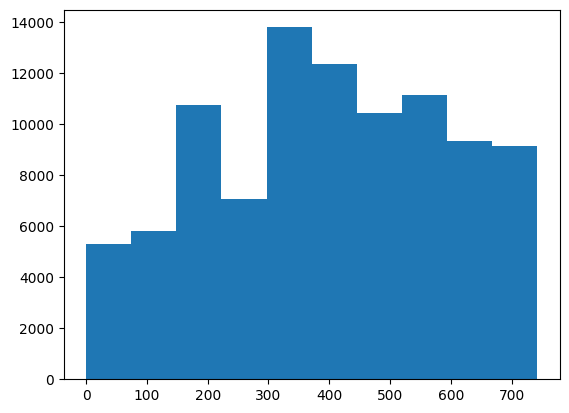

In [24]:
plot.figure()

plot.hist(gt_assignments)

plot.show()

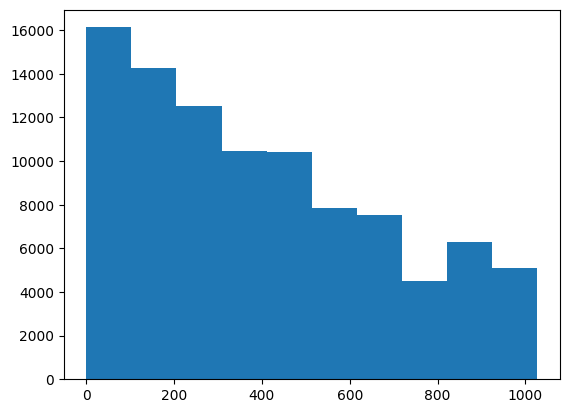

In [25]:
plot.figure()

plot.hist(lv_assignments)

plot.show()

Runs found : 48
Mean score : 6794.9792
95% CI     : [6071.4000, 7807.6500]


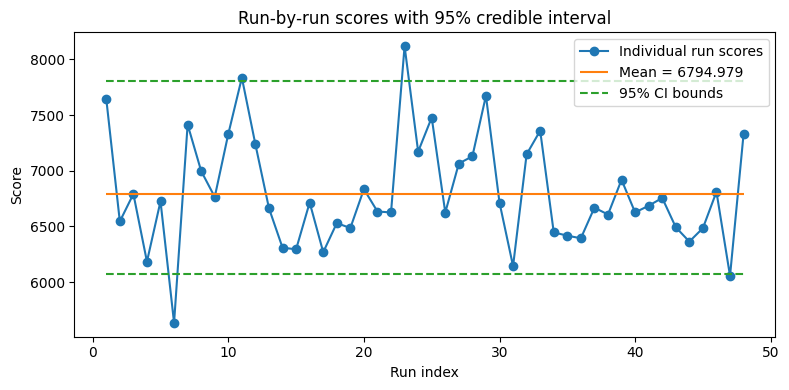

In [26]:
scores = []

for i in range(48):
    pca_cluster_assignment_dict = np.load(f"runs/pca_cluster_assignment_dict_tuned_{i+1}.npy", allow_pickle=True).item()
    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    pca_assignments = np.array([pca_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_pca, _ = compare_two_assignments(gt_assignments, pca_assignments)
    scores.append(score_pca)
    
scores = np.array(scores)
mean_score = scores.mean()
lower, upper = np.percentile(scores, [2.5, 97.5])

print(f"Runs found : {len(scores)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower:.4f}, {upper:.4f}]")

runs = np.arange(1, len(scores) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower, upper], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
std_score = scores.std(ddof=1)
std_score

np.float64(494.1207746920478)

Runs found : 49
Mean score : 17527.1429
95% CI     : [15033.6000, 21537.2000]


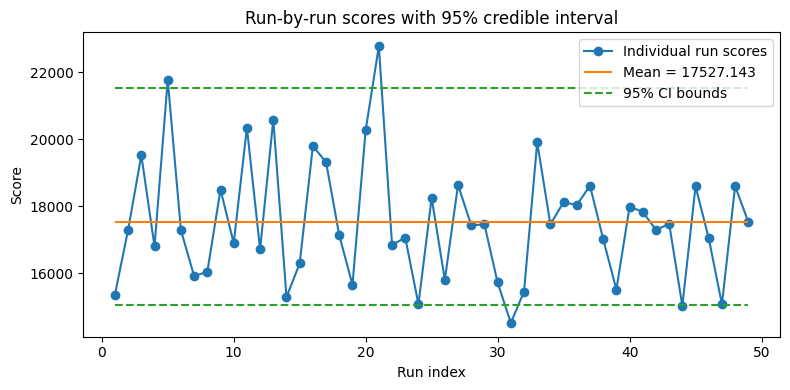

In [28]:
scores_sbm = []

for i in range(49):
    sbm_cluster_assignment_dict = np.load(f"runs_sbm/sbm_{i}/cluster_assignment_dict.npy", allow_pickle=True).item()
    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(sbm_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    sbm_assignments = np.array([sbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_sbm, _ = compare_two_assignments(gt_assignments, sbm_assignments)
    scores_sbm.append(score_sbm)
    
scores_sbm = np.array(scores_sbm)
mean_score = scores_sbm.mean()
lower_sbm, upper_sbm = np.percentile(scores_sbm, [2.5, 97.5])

print(f"Runs found : {len(scores_sbm)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower_sbm:.4f}, {upper_sbm:.4f}]")

runs = np.arange(1, len(scores_sbm) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores_sbm, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower_sbm, upper_sbm], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
std_score = scores_sbm.std(ddof=1)
std_score

np.float64(1827.5729237616392)

In [30]:
np.log(20000)

np.float64(9.903487552536127)

Runs found : 15
Mean score : 5244.4667
95% CI     : [4283.0000, 7240.0000]


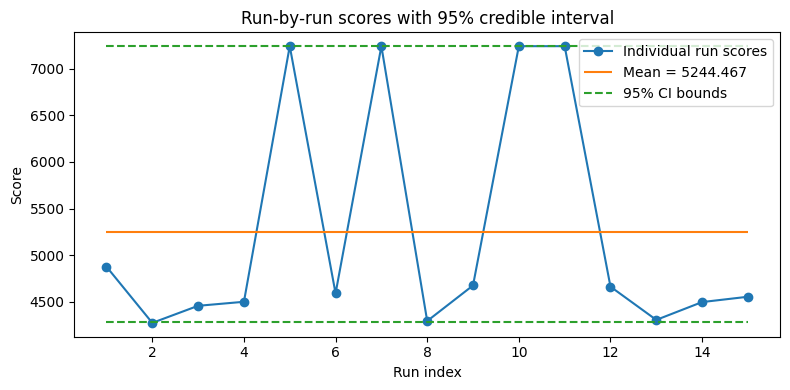

In [31]:
scores_vmog = []

for i in range(15):
    lv_dict_idx = np.load(f"vmog_runs/vmog_cluster_assignment_dict_tuned_{i+1}.npy", allow_pickle=True).item()

    vmog_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                    for idx, lbl in lv_dict_idx.items()
                    if int(idx) in idx2rid }

    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    vmog_assignments = np.array([vmog_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_vmog, _ = compare_two_assignments(gt_assignments, vmog_assignments)
    scores_vmog.append(score_vmog)
    
scores_vmog = np.array(scores_vmog)
mean_score_vmog = scores_vmog.mean()
lower_vmog, upper_vmog = np.percentile(scores_vmog, [2.5, 97.5])

print(f"Runs found : {len(scores_vmog)}")
print(f"Mean score : {mean_score_vmog:.4f}")
print(f"95% CI     : [{lower_vmog:.4f}, {upper_vmog:.4f}]")

runs_vmog = np.arange(1, len(scores_vmog) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_vmog, scores_vmog, 'o-', label="Individual run scores")
plt.hlines(mean_score_vmog, runs_vmog[0], runs_vmog[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_vmog:.3f}")
plt.hlines([lower_vmog, upper_vmog], runs_vmog[0], runs_vmog[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
std_score = scores_vmog.std(ddof=1)
std_score

np.float64(1255.274350585598)

Runs found : 48
Mean score : 2288.6667
95% CI     : [2237.4000, 2345.8500]


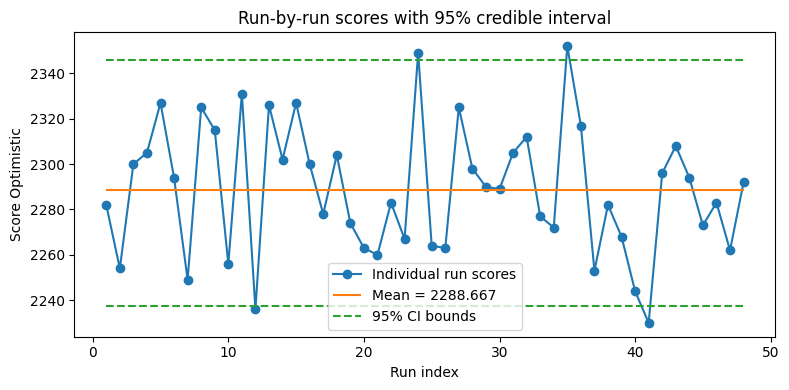

Runs found : 48
Mean score : 1283.6042
95% CI     : [1267.5250, 1300.7750]


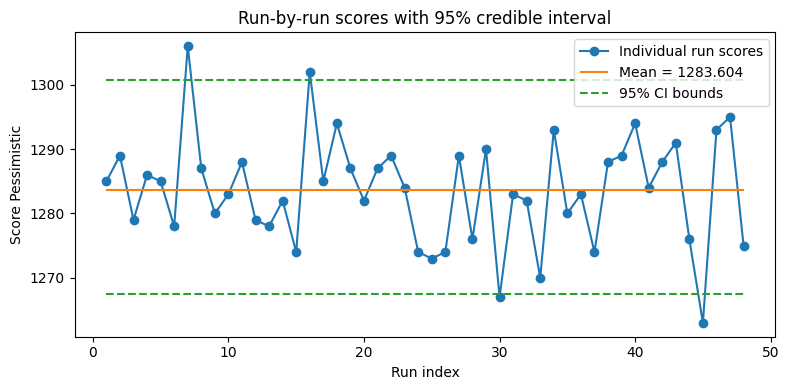

In [33]:
scores_optimistic = []
scores_pessimistic = []

for i in range(48):
    # create a random assignment by randomly permuting `target_assignment`
    random_assignment_optimistic = np.random.permutation(gt_assignments)
    random_assignment_pessimistic = np.random.randint(0, np.unique(gt_assignments).shape[0], gt_assignments.shape[0])
    
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    
    score_optimistic, _ = compare_two_assignments(gt_assignments, random_assignment_optimistic)
    scores_optimistic.append(score_optimistic)
    
    score_pessimistic, _ = compare_two_assignments(gt_assignments, random_assignment_pessimistic)
    scores_pessimistic.append(score_pessimistic)
    
scores_optimistic = np.array(scores_optimistic)
mean_score_optimistic = scores_optimistic.mean()
lower_optimistic, upper_optimistic = np.percentile(scores_optimistic, [2.5, 97.5])

print(f"Runs found : {len(scores_optimistic)}")
print(f"Mean score : {mean_score_optimistic:.4f}")
print(f"95% CI     : [{lower_optimistic:.4f}, {upper_optimistic:.4f}]")

runs_optimistic = np.arange(1, len(scores_optimistic) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_optimistic, scores_optimistic, 'o-', label="Individual run scores")
plt.hlines(mean_score_optimistic, runs_optimistic[0], runs_optimistic[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_optimistic:.3f}")
plt.hlines([lower_optimistic, upper_optimistic], runs_optimistic[0], runs_optimistic[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score Optimistic")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

scores_pessimistic = np.array(scores_pessimistic)
mean_score_pessimistic = scores_pessimistic.mean()
lower_pessimistic, upper_pessimistic = np.percentile(scores_pessimistic, [2.5, 97.5])

print(f"Runs found : {len(scores_pessimistic)}")
print(f"Mean score : {mean_score_pessimistic:.4f}")
print(f"95% CI     : [{lower_pessimistic:.4f}, {upper_pessimistic:.4f}]")

runs_pessimistic = np.arange(1, len(scores_pessimistic) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_pessimistic, scores_pessimistic, 'o-', label="Individual run scores")
plt.hlines(mean_score_pessimistic, runs_pessimistic[0], runs_pessimistic[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_pessimistic:.3f}")
plt.hlines([lower_pessimistic, upper_pessimistic], runs_pessimistic[0], runs_pessimistic[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score Pessimistic")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
std_score = scores_pessimistic.std(ddof=1)
std_score

np.float64(8.47459177033082)

In [35]:
std_score = runs_optimistic.std(ddof=1)
std_score

np.float64(14.0)

In [36]:
# means = [np.mean(scores), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# # Create the figure and axes
# fig, ax = plt.subplots(figsize=(10, 6))

# # Create boxplots
# data = [scores, scores_optimistic, scores_pessimistic]
# box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3])

# # Customize boxplot colors
# colors = ['lightblue', 'lightgreen', 'lightsalmon']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# # Add means as diamond markers
# ax.scatter([1, 2, 3], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# # Add credible intervals as error bars
# ax.errorbar([1, 2, 3], means, yerr=[
#                 [lower, lower_optimistic, lower_pessimistic],
#                 [upper, lower_optimistic, upper_pessimistic]
#             ], fmt='none', color='black', capsize=5, label='95% CI')

# # Add labels and title
# ax.set_ylabel('Scores')
# ax.set_title('Comparison of Score Distributions')
# ax.set_xticks([1, 2, 3])
# ax.set_xticklabels(['PCA Kmeans', 'Random Optimistic', 'Random Pessimistic'])

# # Add grid lines
# ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# # Add legend
# ax.legend()

# # Show the plot
# plt.tight_layout()
# plt.show()

In [37]:
np.log(6775.0208)

np.float64(8.82099771585389)

In [38]:
means = [np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

In [39]:
print(lower)

6071.4


In [40]:
print(means)

[np.float64(6794.979166666667), np.float64(5244.466666666666), np.float64(2288.6666666666665), np.float64(1283.6041666666667)]


In [41]:
print(lower_pessimistic)

1267.525


In [42]:
upper

np.float64(7807.65)

In [43]:
[-means[0] + upper, -means[1] + upper_vmog, -means[2] + lower_optimistic, -means[3] + upper_pessimistic]

[np.float64(1012.6708333333327),
 np.float64(1995.5333333333338),
 np.float64(-51.266666666666424),
 np.float64(17.17083333333312)]

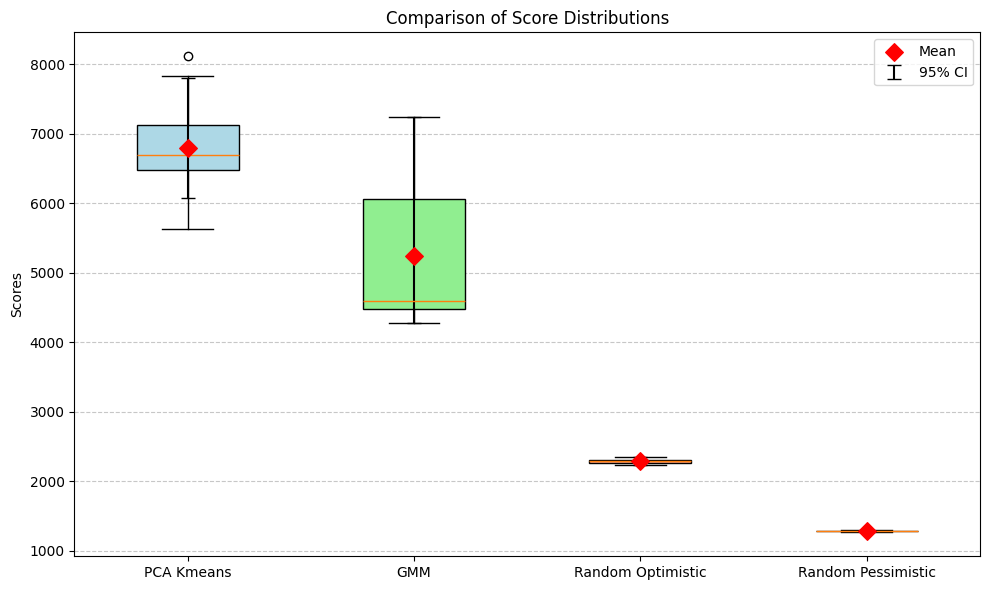

In [44]:
means = [np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots
data = [scores, scores_vmog, scores_optimistic, scores_pessimistic]
box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3, 4])

# Customize boxplot colors
colors = ['lightblue', 'lightgreen', 'lightsalmon', 'lavender']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add means as diamond markers
ax.scatter([1, 2, 3, 4], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# Add credible intervals as error bars
ax.errorbar([1, 2, 3, 4], means, yerr=[
                [means[0] - lower, means[1] - lower_vmog, means[2] - lower_optimistic, means[3] - lower_pessimistic],
                [-means[0] + upper, -means[1] + upper_vmog, -means[2] + upper_optimistic, -means[3] + upper_pessimistic]
            ], fmt='none', color='black', capsize=5, label='95% CI')

# Add labels and title
ax.set_ylabel('Scores')
ax.set_title('Comparison of Score Distributions')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic'])

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [45]:
my_list = [95000] * 48

In [46]:
gt = np.array(my_list)
gt

array([95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000])

In [47]:
np.mean(scores_pessimistic)

np.float64(1283.6041666666667)

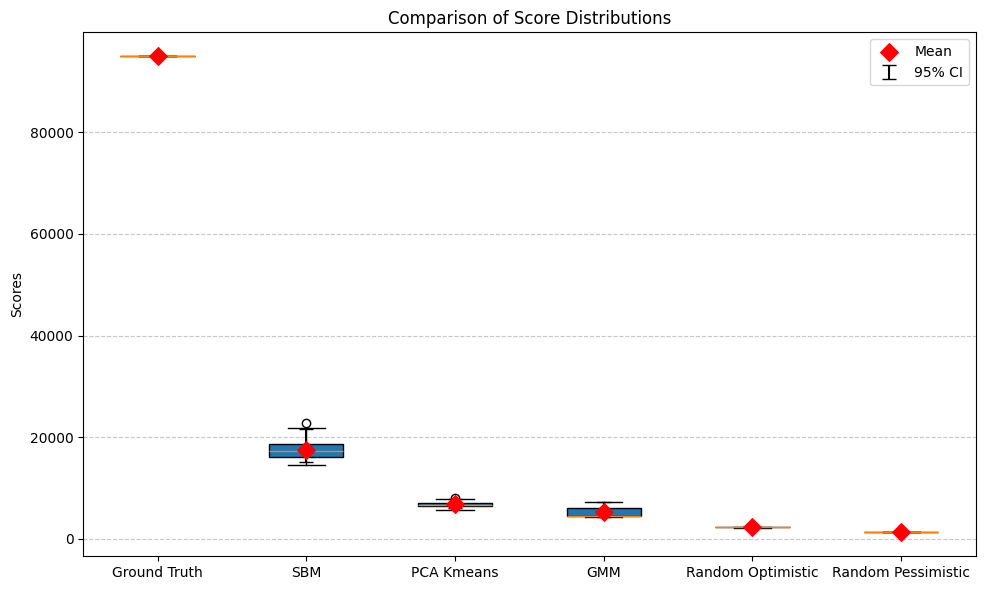

In [48]:
means = [95000, np.mean(scores_sbm), np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots
data = [gt, scores_sbm, scores, scores_vmog, scores_optimistic, scores_pessimistic]
box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3, 4, 5, 6])

# Customize boxplot colors
# colors = ['red', 'lightblue', 'lightgreen', 'lightsalmon', 'lavender']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# Add means as diamond markers
ax.scatter([1, 2, 3, 4, 5, 6], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# Add credible intervals as error bars
ax.errorbar([1, 2, 3, 4, 5, 6], means, yerr=[
                [0, means[1] - lower_sbm, means[2] - lower, means[3] - lower_vmog, means[4] - lower_optimistic, means[5] - lower_pessimistic],
                [0, -means[1] + upper_sbm, -means[2] + upper, -means[3] + upper_vmog, -means[4] + upper_optimistic, -means[5] + upper_pessimistic]
            ], fmt='none', color='black', capsize=5, label='95% CI')

# Add labels and title
ax.set_ylabel('Scores')
ax.set_title('Comparison of Score Distributions')
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xticklabels(['Ground Truth', 'SBM', 'PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic'])

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend()

# Show the plot

plt.tight_layout()

plt.show()


C:\Users\ROG\AppData\Local\Temp\ipykernel_22484\2798411438.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


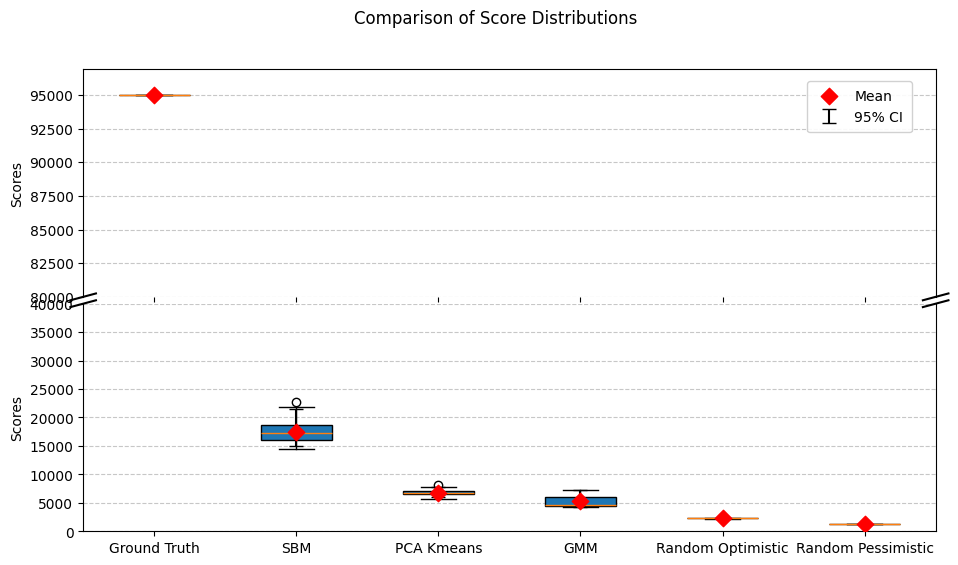

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 原有数据准备（保持不变）----
means = [95000, np.mean(scores_sbm), np.mean(scores), np.mean(scores_vmog),
         np.mean(scores_optimistic), np.mean(scores_pessimistic)]

positions = [1, 2, 3, 4, 5, 6]
labels = ['Ground Truth', 'SBM', 'PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic']
data = [gt, scores_sbm, scores, scores_vmog, scores_optimistic, scores_pessimistic]

# 计算上轴的最大 y（覆盖均值和 CI 上界）
ymax_candidates = []
for arr in data:
    if len(arr) > 0:
        ymax_candidates.append(np.nanmax(np.asarray(arr)))
ymax_candidates += [m for m in means if m is not None]
ymax_candidates += [upper_sbm, upper, upper_vmog, upper_optimistic, upper_pessimistic]
ymax = max(ymax_candidates) * 1.02  # 稍微留白

# ---- 断轴：两个共享 x 的子图（上：高区间；下：低区间）----
fig, (ax_hi, ax_lo) = plt.subplots(
    2, 1, sharex=True, figsize=(11, 6),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.03}
)

def draw_on(ax, add_legend=False):
    # 盒须图
    box = ax.boxplot(data, patch_artist=True, positions=positions)

    # 均值（菱形）
    ax.scatter(positions, means, marker='D', color='red', s=70, zorder=3,
               label=('Mean' if add_legend else None))

    # 95% CI（误差棒）
    ax.errorbar(
        positions, means,
        yerr=[
            [0, means[1] - lower_sbm, means[2] - lower, means[3] - lower_vmog, means[4] - lower_optimistic, means[5] - lower_pessimistic],
            [0, -means[1] + upper_sbm, -means[2] + upper, -means[3] + upper_vmog, -means[4] + upper_optimistic, -means[5] + upper_pessimistic]
        ],
        fmt='none', color='black', capsize=5,
        label=('95% CI' if add_legend else None)
    )

    # 网格线
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# 在两个轴上各画一遍
draw_on(ax_hi, add_legend=True)
draw_on(ax_lo, add_legend=False)

# y 范围：掐掉 40k~80k
ax_lo.set_ylim(0, 40000)        # 低区间
ax_hi.set_ylim(80000, ymax)     # 高区间

# 断轴视觉标记（斜杠）
for ax, which in [(ax_hi, 'bottom'), (ax_lo, 'top')]:
    ax.spines[which].set_visible(False)
ax_hi.tick_params(labeltop=False)  # 上轴不显示 x 轴刻度标签
ax_lo.xaxis.tick_bottom()

d = .015  # 斜杠长度
kwargs_hi = dict(transform=ax_hi.transAxes, color='k', clip_on=False)
ax_hi.plot((-d, +d), (-d, +d), **kwargs_hi)
ax_hi.plot((1 - d, 1 + d), (-d, +d), **kwargs_hi)
kwargs_lo = dict(transform=ax_lo.transAxes, color='k', clip_on=False)
ax_lo.plot((-d, +d), (1 - d, 1 + d), **kwargs_lo)
ax_lo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_lo)

# X 轴标签和标题
ax_lo.set_xticks(positions)
ax_lo.set_xticklabels(labels, rotation=0)
ax_lo.set_ylabel('Scores')
ax_hi.set_ylabel('Scores')

fig.suptitle('Comparison of Score Distributions (broken y-axis)')

# === 修改部分：把图例放到整张图的上方居中 ===

# 标题（保持居中）
fig.suptitle('Comparison of Score Distributions')

# 在上半轴内部右上角放图例（不盖住标题）
leg = ax_hi.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),   # 轻微内缩，避免贴边
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
    fontsize=10
)

# 紧凑布局；因为图例放在轴内部，给标题预留一点空间即可
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [120]:
# should we be expecting higher variance from GMM?

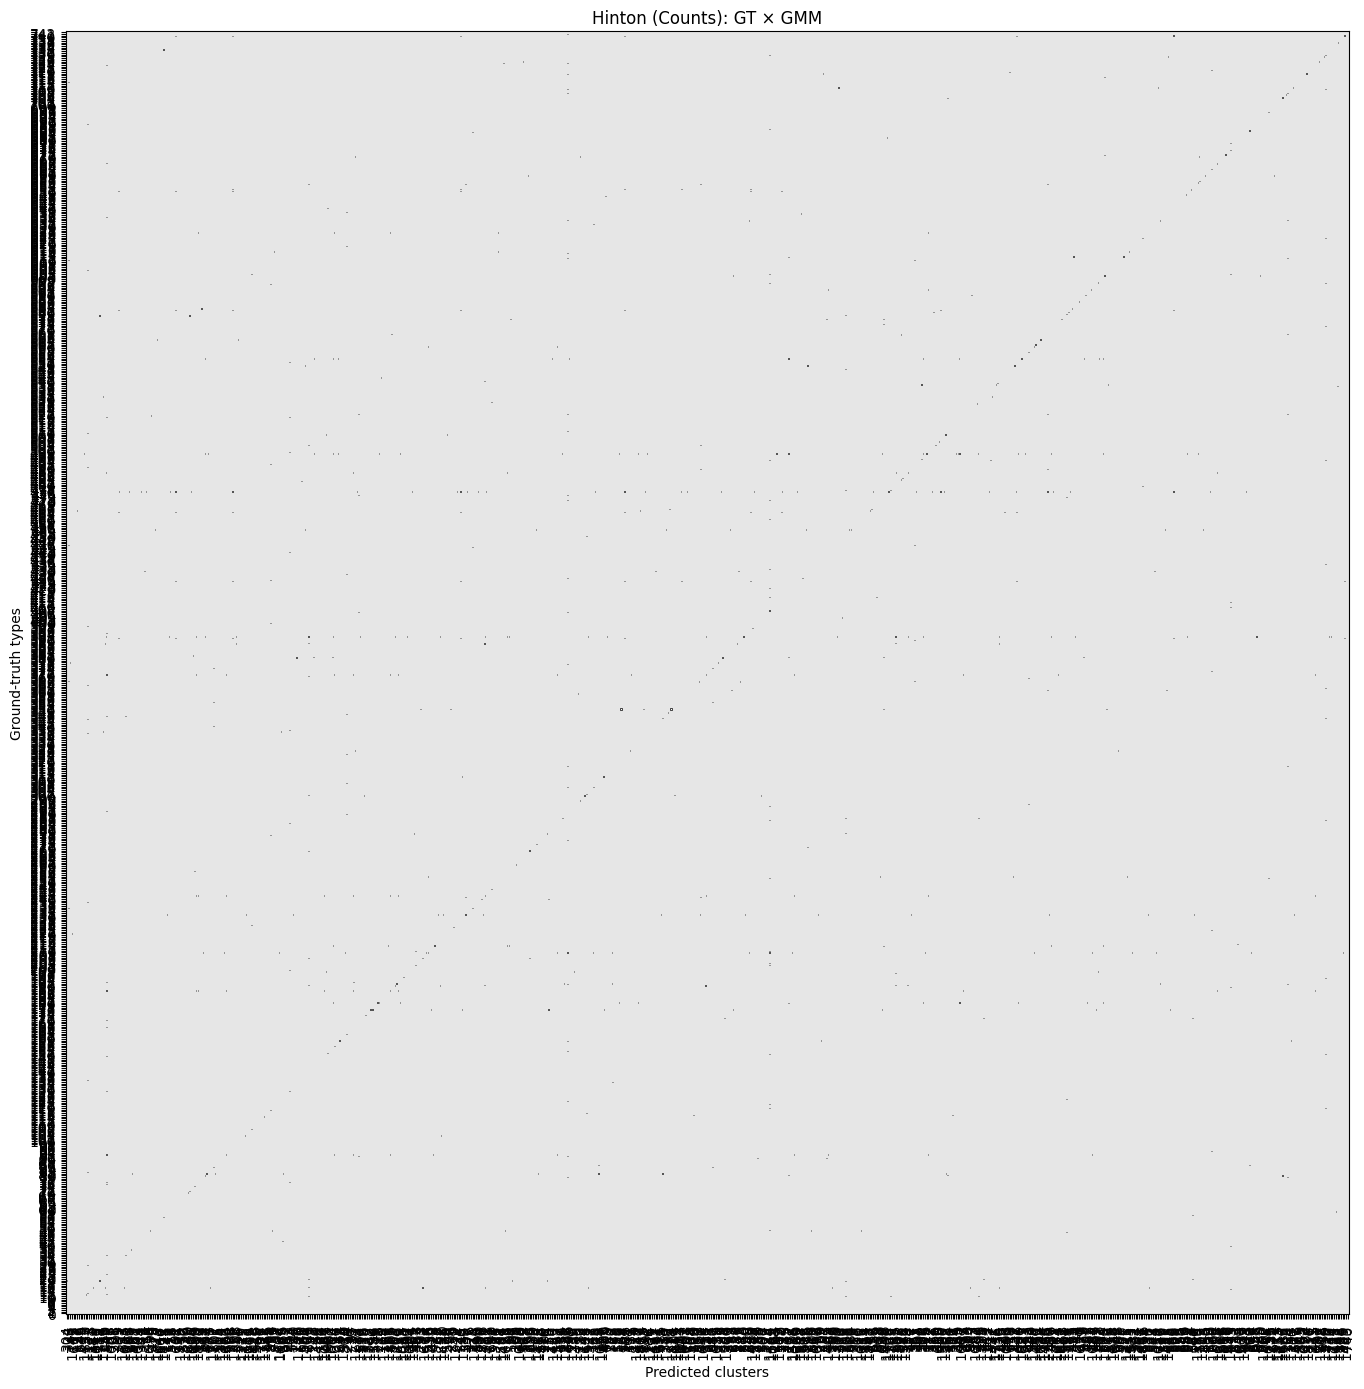

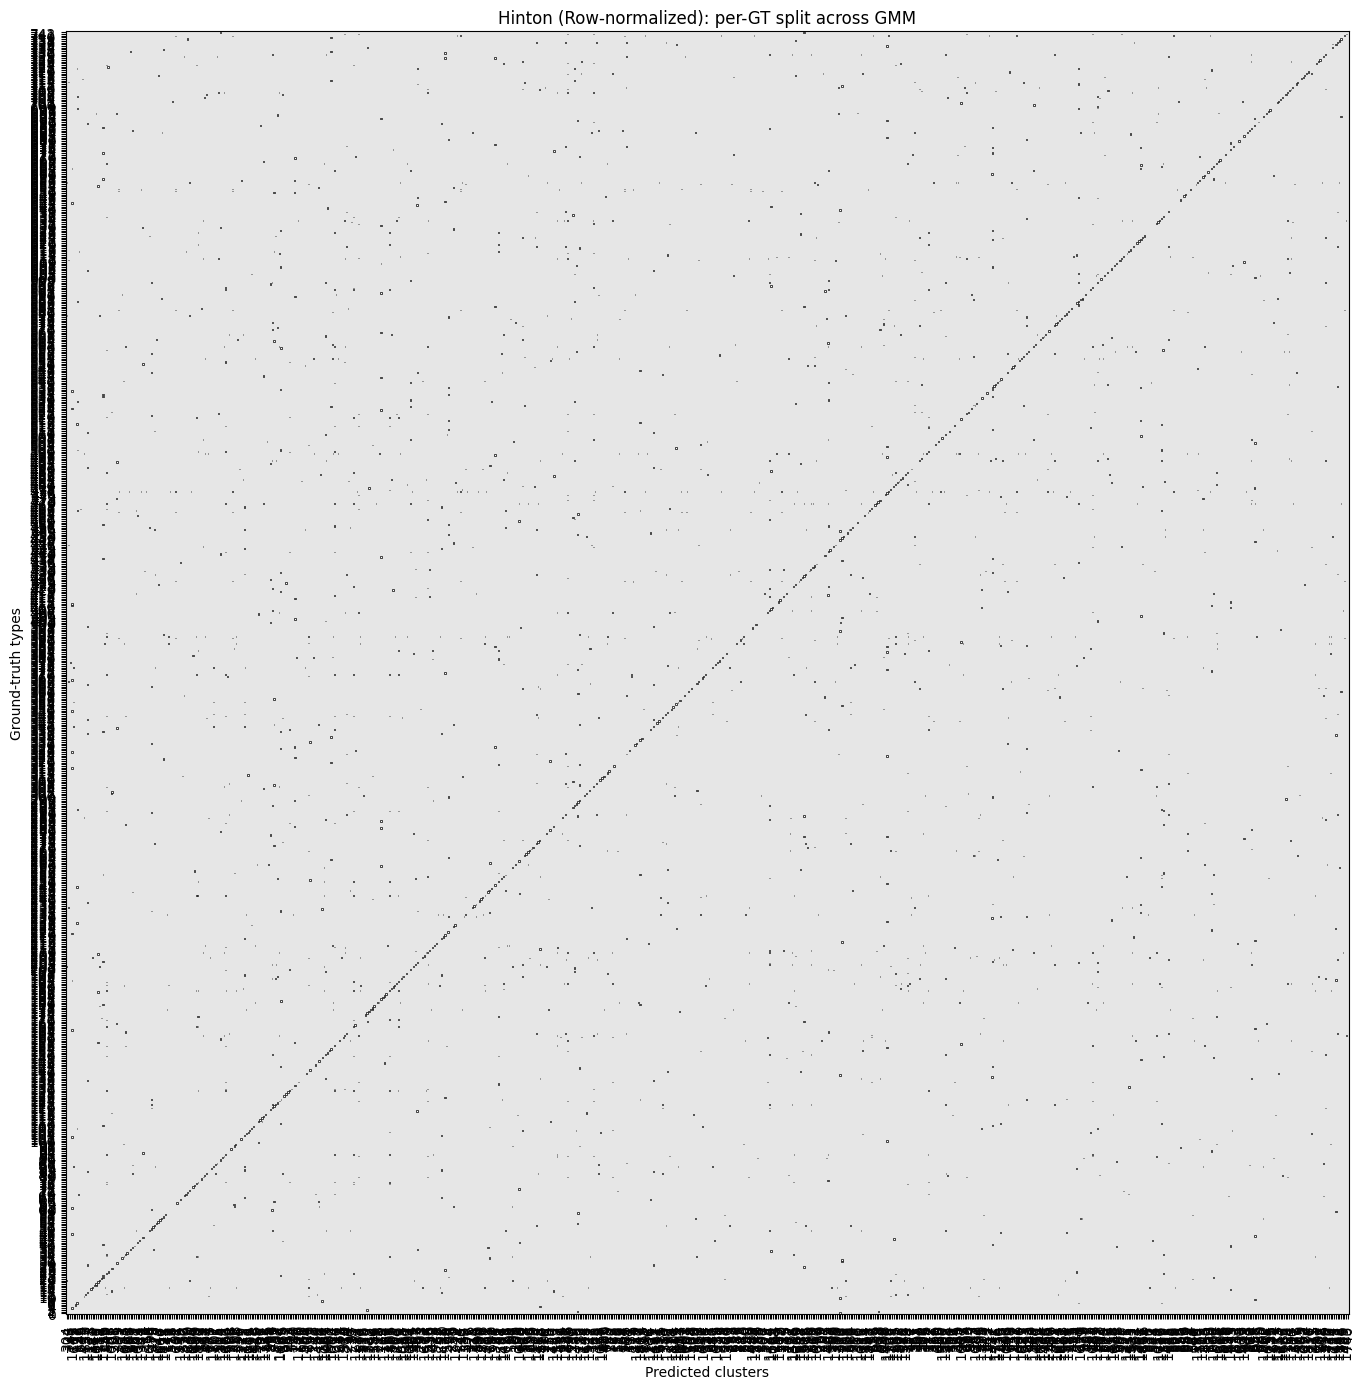

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 81,  0,  0],
       [ 0,  0,  0, ...,  0, 24,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 743))

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment

def make_consecutive_labels(y):
    y = np.asarray(y)
    uniq = np.unique(y)
    remap = {v: i for i, v in enumerate(uniq)}
    return np.array([remap[v] for v in y]), [str(v) for v in uniq]

def contingency_matrix(y_true, y_pred):
    C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
    np.add.at(C, (y_true, y_pred), 1)
    return C

def align_columns_by_hungarian(C):
    r, c = linear_sum_assignment(-C)
    return C[:, c], c

def hinton(ax, M, max_weight=None):
    ax.cla()
    h, w = M.shape
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
    ax.set_aspect('equal', 'box')
    ax.set_facecolor('0.9')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    for (i, j), v in np.ndenumerate(M):
        if v <= 0: continue
        s = np.sqrt(v / max_weight)
        rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                             facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)

def plot_hinton_gt_vs_pred(y_gt, y_pred, row_names=None, col_names=None,
                           normalize='none', align=True, title='Hinton'):
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]
    C_plot = C.astype(float)
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs==0]=1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs==0]=1
        C_plot = C_plot / cs

    # fig, ax = plt.subplots(figsize=(min(18, 2+0.5*C.shape[1]), min(14, 2+0.5*C.shape[0])))
    fig, ax = plt.subplots(
    figsize=(min(18, 2+0.5*C.shape[1]),  # width ∝ #cols
             min(14, 2+0.5*C.shape[0]))  # height ∝ #rows
)

    hinton(ax, C_plot)
    ax.set_title(title); ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
    ax.set_xticks(np.arange(C.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C.shape[0]) + 0.5)
    ax.set_xticklabels(col_names if col_names is not None else [f'c{j}' for j in range(C.shape[1])], rotation=90)
    ax.set_yticklabels(row_names if row_names is not None else [f't{i}' for i in range(C.shape[0])])
    plt.tight_layout(); plt.show()
    return C

#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='none', align=True,
    title='Hinton (Counts): GT × GMM'
)

#5 draw row-normalized hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across SBM'
)

In [122]:
print("Number of ground-truth types:", len(np.unique(y_gt_i)))
print("Number of predicted clusters:", len(np.unique(y_ro_i)))

Number of ground-truth types: 743
Number of predicted clusters: 1068


In [123]:
with open("root_id_to_index_mapping.json", "r") as f:
    rid2idx = json.load(f)                     
idx2rid = {int(v): int(k) for k, v in rid2idx.items()}

lv_dict_idx = np.load('vmog_runs/vmog_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

lv_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                 for idx, lbl in lv_dict_idx.items()
                 if int(idx) in idx2rid }

shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys()))
                                     .intersection(set(lv_cluster_assignment_dict.keys()))
                                        .intersection(set(sbm_cluster_assignment_dict.keys())))


lv_assignments = np.array([lv_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
y_KM_i, names = make_consecutive_labels(lv_assignments)
print("Number of predicted clusters:", len(np.unique(y_KM_i)))

Number of predicted clusters: 542


In [124]:
unique_labels = np.unique(lv_assignments)
print("Unique cluster IDs:", unique_labels[:20], "...")
print("Total clusters present:", len(unique_labels))

Unique cluster IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ...
Total clusters present: 542


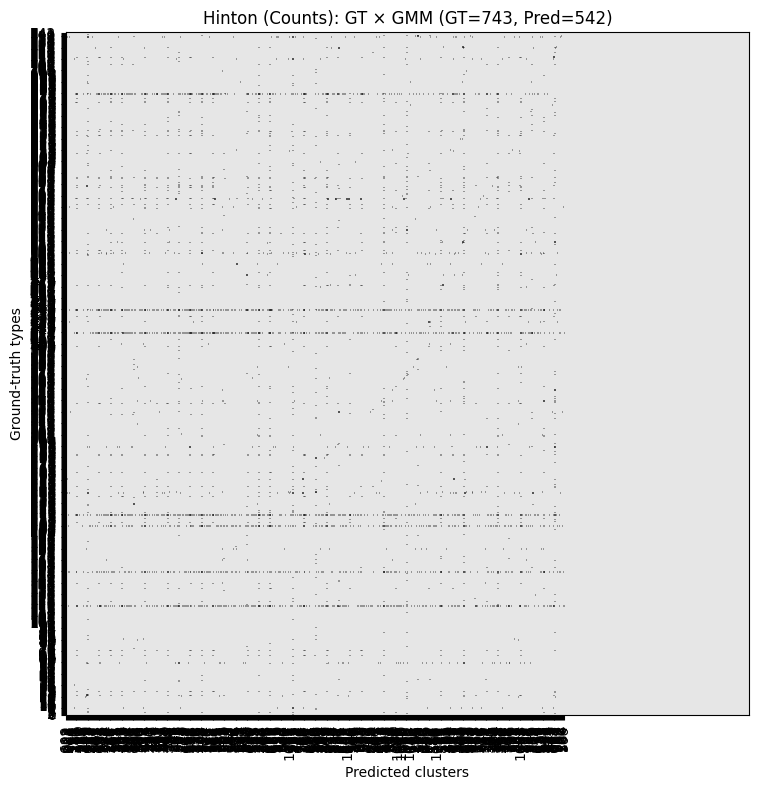

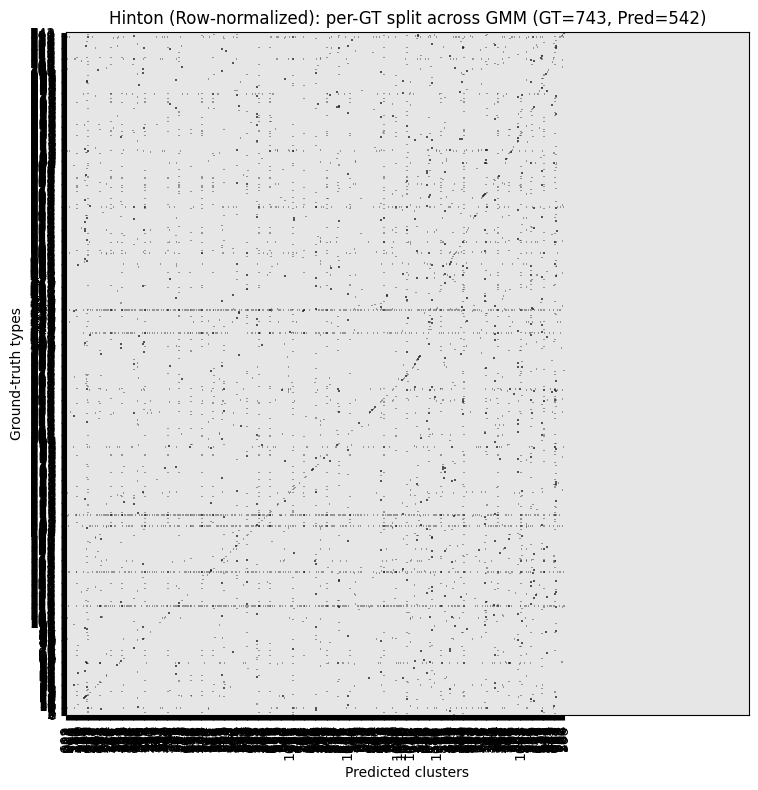

array([[ 4,  0,  0, ...,  0,  1,  0],
       [ 0,  9,  0, ...,  0,  0,  0],
       [ 0,  0,  1, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 11,  0,  0],
       [ 0,  0,  0, ...,  0,  5,  0],
       [ 0,  0,  0, ...,  0,  0,  2]], shape=(743, 542))

In [125]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment

def make_consecutive_labels(y):
    y = np.asarray(y)
    uniq = np.unique(y)
    remap = {v: i for i, v in enumerate(uniq)}
    return np.array([remap[v] for v in y]), [str(v) for v in uniq]

def contingency_matrix(y_true, y_pred):
    C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
    np.add.at(C, (y_true, y_pred), 1)
    return C

def align_columns_by_hungarian(C):
    r, c = linear_sum_assignment(-C)
    return C[:, c], c

def hinton(ax, M, max_weight=None):
    ax.cla()
    h, w = M.shape
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
    ax.set_aspect('equal', 'box')
    ax.set_facecolor('0.9')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    for (i, j), v in np.ndenumerate(M):
        if v <= 0: continue
        s = np.sqrt(v / max_weight)
        rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                             facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
def plot_hinton_gt_vs_pred(y_gt, y_pred, row_names=None, col_names=None,
                           normalize='none', align=True, title='Hinton',
                           pad_to_square=True):
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]
    C_plot = C.astype(float)
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs==0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs==0] = 1
        C_plot = C_plot / cs

    # --- pad to square ---
    if pad_to_square:
        n = max(C_plot.shape)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:C_plot.shape[0], :C_plot.shape[1]] = C_plot
    else:
        S = C_plot

    # --- make figure square ---
    fig, ax = plt.subplots(figsize=(8, 8))  # 正方形画布
    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    # 只显示真实的刻度，不显示填充部分
    ax.set_xticks(np.arange(C.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C.shape[0]) + 0.5)
    ax.set_xticklabels(
        col_names if col_names is not None else [f'c{j}' for j in range(C.shape[1])],
        rotation=90
    )
    ax.set_yticklabels(
        row_names if row_names is not None else [f't{i}' for i in range(C.shape[0])]
    )
    ax.set_xlim(0, S.shape[1]); ax.set_ylim(0, S.shape[0])

    plt.tight_layout()
    plt.show()
    return C


#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='none', align=True,
    title='Hinton (Counts): GT × GMM'
)

#5 draw row-normalized hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across GMM'
)

In [ ]:
a = 2695/371
a

7.264150943396227

In [ ]:
y = [21, 59, 25, 127]
x = [4, 9, 7, 15]
t = 0
for i in range(len(y)):
    t += (y[i] - x[i]*a)**2

t/4

274.7783018867925

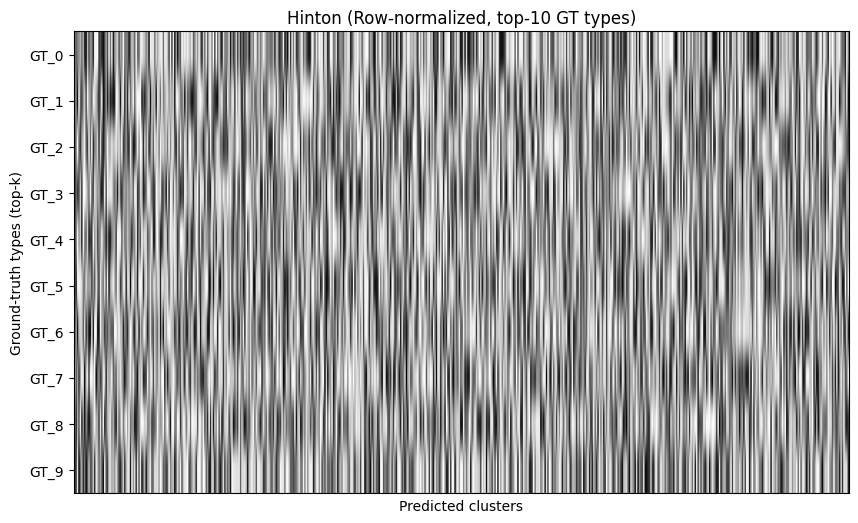

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Let's simulate a similar Hinton diagram with fewer labels (top-k GT types)
# Since we don't have the actual plotting code yet, I'll create a function that
# trims the matrix to top-k rows for visualization.

def plot_hinton_topk(matrix, gt_labels, pred_labels, top_k=10):
    """
    Plot a simplified Hinton diagram with only the top_k ground-truth rows.
    
    Args:
        matrix (np.ndarray): Row-normalized GT x Pred matrix.
        gt_labels (list): Ground-truth type labels.
        pred_labels (list): Predicted cluster labels.
        top_k (int): Number of top GT types to show.
    """
    # Select top_k rows (e.g., first top_k)
    matrix_topk = matrix[:top_k, :]
    gt_labels_topk = gt_labels[:top_k]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(matrix_topk, cmap="Greys", aspect="auto")
    
    # Set ticks
    ax.set_yticks(np.arange(top_k))
    ax.set_yticklabels(gt_labels_topk)
    ax.set_xticks([])  # avoid cluttered x-axis
    ax.set_xlabel("Predicted clusters")
    ax.set_ylabel("Ground-truth types (top-k)")
    ax.set_title(f"Hinton (Row-normalized, top-{top_k} GT types)")
    
    plt.show()

# Example: simulate a 743x542 matrix and visualize top-10 rows
np.random.seed(0)
matrix = np.random.rand(743, 542)
matrix = matrix / matrix.sum(axis=1, keepdims=True)  # row normalize
gt_labels = [f"GT_{i}" for i in range(743)]
pred_labels = [f"Pred_{j}" for j in range(542)]

plot_hinton_topk(matrix, gt_labels, pred_labels, top_k=10)


In [53]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=True,
    top_k_rows=None, top_k_cols=None, top_by='count', keep_rest_as_other=True
):
    """
    新增特性：
      - top_k_rows / top_k_cols：只显示Top-K行/列，其他可合并为'Other'
      - top_by: 'count' 或 'mass'
    """

    # --- 原流程：构造与可选对齐 ---
    C = contingency_matrix(y_gt, y_pred)
    if align:
        try:
            from scipy.optimize import linear_sum_assignment
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            # 没有scipy或对齐失败则忽略
            pass

    # 初始标签兜底
    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    # 归一化（如果需要）
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # --- 选择Top-K行 ---
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        if top_by == 'count':
            # 用原始计数衡量行规模
            row_score = C.sum(axis=1)
        else:  # 'mass'
            row_score = C_plot.sum(axis=1)
        top_idx = np.argsort(row_score)[::-1][:top_k_rows]
        rest_idx = np.setdiff1d(np.arange(C_plot.shape[0]), top_idx)

        C_rows = C_plot[top_idx, :]
        names_rows = [row_names[i] for i in top_idx]

        if keep_rest_as_other and rest_idx.size > 0:
            other_row = C_plot[rest_idx, :].sum(axis=0, keepdims=True)
            C_rows = np.vstack([C_rows, other_row])
            names_rows.append('Other')

        C_plot = C_rows
        row_names = names_rows

    # --- 选择Top-K列 ---
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        if top_by == 'count':
            col_score = C.sum(axis=0)
        else:  # 'mass'
            col_score = C_plot.sum(axis=0)
        top_j = np.argsort(col_score)[::-1][:top_k_cols]
        rest_j = np.setdiff1d(np.arange(C_plot.shape[1]), top_j)

        C_cols = C_plot[:, top_j]
        names_cols = [col_names[j] for j in top_j]

        if keep_rest_as_other and rest_j.size > 0:
            other_col = C_plot[:, rest_j].sum(axis=1, keepdims=True)
            C_cols = np.hstack([C_cols, other_col])
            names_cols.append('Other')

        C_plot = C_cols
        col_names = names_cols

    # --- pad to square ---
    if pad_to_square:
        n = max(C_plot.shape)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:C_plot.shape[0], :C_plot.shape[1]] = C_plot
    else:
        S = C_plot

    # --- 画图（保持正方形画布） ---
    fig, ax = plt.subplots(figsize=(8, 8))
    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[0]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    # 只显示真实的刻度
    ax.set_xticks(np.arange(C_plot.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C_plot.shape[0]) + 0.5)
    ax.set_xticklabels(col_names, rotation=90)
    ax.set_yticklabels(row_names)

    ax.set_xlim(0, S.shape[1]); ax.set_ylim(0, S.shape[0])
    plt.tight_layout()
    plt.show()
    return C


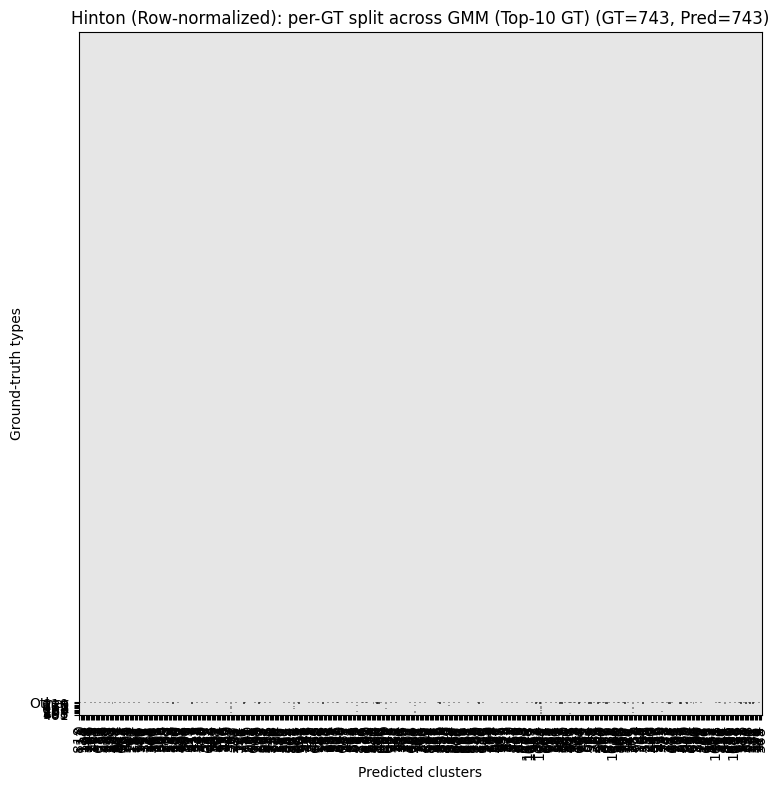

array([[22,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  2,  0],
       [ 0,  0,  0, ...,  0,  0,  6],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 542))

In [54]:

#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across GMM (Top-10 GT)',
    top_k_rows=10, top_k_cols=None, top_by='count', keep_rest_as_other=True
)


In [59]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=False,               # 关键：默认改为 False
    top_k_rows=None, top_k_cols=None,  # 仅裁剪，不合并“Other”
    top_by='count'                     # 'count' or 'mass'
):
    C = contingency_matrix(y_gt, y_pred)

    if align:
        try:
            from scipy.optimize import linear_sum_assignment
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            pass

    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    # 归一化（若需要）
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # ---- 仅裁剪 Top-K 行（不合并“Other”）----
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        if top_by == 'count':
            row_score = C.sum(axis=1)
        else:  # 'mass'
            row_score = C_plot.sum(axis=1)
        top_i = np.argsort(row_score)[::-1][:top_k_rows]
        C_plot = C_plot[top_i, :]
        row_names = [row_names[i] for i in top_i]

    # ---- 仅裁剪 Top-K 列（不合并“Other”）----
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        if top_by == 'count':
            col_score = C.sum(axis=0)
        else:
            col_score = C_plot.sum(axis=0)
        top_j = np.argsort(col_score)[::-1][:top_k_cols]
        C_plot = C_plot[:, top_j]
        col_names = [col_names[j] for j in top_j]

    # ---- 不再 pad 成方阵（避免大片灰色留白）----
    S = C_plot
    H, W = S.shape

    # 根据内容自适应画布宽高：行少时更扁、列多时更宽
    # 你也可以直接写成固定值，比如 figsize=(8, 5)
    fig_w = max(6, min(16, 0.03 * W + 6))
    fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    hinton(ax, S)  # 用当前尺寸的矩阵作图
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[0]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    # 只为当前子矩阵设置刻度与标签
    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    # X 轴标签太多会重叠：做一个稀疏显示（每隔 n 个显示一个）
    if W > 60:
        step = int(np.ceil(W / 60))  # 保持最多 ~60 个标签
        xticklabels = [lbl if i % step == 0 else '' for i, lbl in enumerate(col_names)]
    else:
        xticklabels = col_names
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names, fontsize=9)

    plt.tight_layout()
    plt.show()
    return C


In [51]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=False,
    top_k_rows=None, top_k_cols=None,
    top_by='count',                 # 兼容：若下面两个未设置，行列都用它
    top_by_rows=None, top_by_cols=None
):
    """
    Hinton diagram with radix-style sorting (rows & cols), then Top-K selection.

    - Radix排序键（稳定排序，先次键后主键）:
        主键: 'strength' = 行/列强度 (count 或 mass)
        次键: 行/列最大峰值 peak (降序)
        第三键: 熵 entropy (升序，越小越集中)
    - 排序完成后再按 top_k_rows / top_k_cols 截取
    """
    # -------------------- helpers --------------------
    def contingency_matrix(y_true, y_pred):
        C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
        np.add.at(C, (y_true, y_pred), 1)
        return C

    def align_columns_by_hungarian(C):
        # 对 counts 做对齐；后续我们仍会再做排序
        from scipy.optimize import linear_sum_assignment
        r, c = linear_sum_assignment(-C)
        return C[:, c], c

    def hinton(ax, M, max_weight=None):
        ax.cla()
        h, w = M.shape
        if max_weight is None:
            max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
        ax.set_aspect('equal', 'box')
        ax.set_facecolor('0.9')
        ax.set_xlim(0, w); ax.set_ylim(0, h)
        for (i, j), v in np.ndenumerate(M):
            if v <= 0: 
                continue
            s = np.sqrt(v / max_weight)
            rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                                 facecolor='white', edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

    # -------------------- base matrices --------------------
    C = contingency_matrix(y_gt, y_pred)

    if align:
        try:
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            pass

    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    # -------- normalization (affects mass/peak/entropy) --------
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # 默认行列的 top_by
    if top_by_rows is None: top_by_rows = top_by
    if top_by_cols is None: top_by_cols = top_by

    # -------------------- RADIX SORT: ROWS --------------------
    # 度量
    row_count   = C.sum(axis=1).astype(float)   # 行样本数（未归一化）
    row_mass    = C_plot.sum(axis=1)            # 行“质量”（受归一化影响）
    row_peak    = C_plot.max(axis=1)            # 行最大峰值
    eps = 1e-12
    row_entropy = -(C_plot * np.log(C_plot + eps)).sum(axis=1)  # 越小越集中

    primary_row_strength = row_count if top_by_rows == 'count' else row_mass

    # 稳定排序：先第三键(熵↑)、再第二键(峰↓)、最后主键(强度↓)
    order_rows = np.arange(C_plot.shape[0])
    order_rows = order_rows[np.argsort(row_entropy[order_rows], kind='stable')]          # ↑
    order_rows = order_rows[np.argsort(-row_peak[order_rows], kind='stable')]            # ↓
    order_rows = order_rows[np.argsort(-primary_row_strength[order_rows], kind='stable')]# ↓

    C_plot   = C_plot[order_rows, :]
    row_names = [row_names[i] for i in order_rows]
    # 注意：这里暂不截取 top_k_rows，先把列也排序完（列的统计尽量用完整行）

    # -------------------- RADIX SORT: COLS --------------------
    # 使用当前 C_plot（行已重排但未截取），对列做度量
    col_count   = C.sum(axis=0).astype(float)
    col_mass    = C_plot.sum(axis=0)
    col_peak    = C_plot.max(axis=0)
    # 列的“熵”：看列向各行的分布
    col_probs = C_plot / (C_plot.sum(axis=0, keepdims=True) + eps)
    col_entropy = -(col_probs * np.log(col_probs + eps)).sum(axis=0)

    primary_col_strength = col_count if top_by_cols == 'count' else col_mass

    order_cols = np.arange(C_plot.shape[1])
    order_cols = order_cols[np.argsort(col_entropy[order_cols], kind='stable')]          # ↑
    order_cols = order_cols[np.argsort(-col_peak[order_cols], kind='stable')]            # ↓
    order_cols = order_cols[np.argsort(-primary_col_strength[order_cols], kind='stable')]# ↓

    C_plot    = C_plot[:, order_cols]
    col_names  = [col_names[j] for j in order_cols]

    # -------------------- select Top-K after sorting --------------------
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        C_plot    = C_plot[:top_k_rows, :]
        row_names = row_names[:top_k_rows]

    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        C_plot    = C_plot[:, :top_k_cols]
        col_names = col_names[:top_k_cols]

    # -------------------- plot --------------------
    S = C_plot
    H, W = S.shape

    # 自适应画布
    fig_w = max(6, min(16, 0.03 * W + 6))
    fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")  # 修正 Pred 计数
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    # 稀疏 x 轴标签
    if W > 60:
        step = int(np.ceil(W / 60))
        xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
    else:
        xticklabels = col_names
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names, fontsize=9)

    plt.tight_layout()
    plt.show()
    return C


In [56]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=False,
    top_k_rows=None, top_k_cols=None,
    top_by='count',
    corner='tr'               # 'tl'|'tr'|'bl'|'br'  把大配对块放到哪个角
):
    # ---- helpers ----
    def contingency_matrix(y_true, y_pred):
        C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
        np.add.at(C, (y_true, y_pred), 1)
        return C

    def align_columns_by_hungarian(C):
        try:
            from scipy.optimize import linear_sum_assignment
            r, c = linear_sum_assignment(-C)
            return C[:, c], c
        except Exception:
            return C, np.arange(C.shape[1])

    def hinton(ax, M, max_weight=None):
        ax.cla()
        h, w = M.shape
        if max_weight is None:
            max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
        ax.set_aspect('equal', 'box'); ax.set_facecolor('0.9')
        ax.set_xlim(0, w); ax.set_ylim(0, h)
        for (i, j), v in np.ndenumerate(M):
            if v <= 0: continue
            s = np.sqrt(v / max_weight)
            rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                                 facecolor='white', edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

    # ---- base ----
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]

    if row_names is None: row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None: col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    # ---- normalize (affects overlaps we sort by) ----
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # ---- sort rows by "how well they are clustered" (peak desc, then count/mass desc) ----
    peak_val = C_plot.max(axis=1)
    peak_col = C_plot.argmax(axis=1)
    strength = (C.sum(axis=1).astype(float) if top_by=='count' else C_plot.sum(axis=1))

    # 行排序：先按峰值，再按强度（都降序），最后稳定按峰列分组
    order_rows = np.arange(C_plot.shape[0])
    order_rows = order_rows[np.argsort(peak_col[order_rows], kind='stable')]      # 分组
    order_rows = order_rows[np.argsort(-strength[order_rows], kind='stable')]     # 强度↓
    order_rows = order_rows[np.argsort(-peak_val[order_rows], kind='stable')]     # 峰值↓

    C_plot  = C_plot[order_rows, :]
    row_names = [row_names[i] for i in order_rows]
    peak_col  = peak_col[order_rows]

    # ---- derive a column order so that row i's best column appears early ----
    # 取行的主峰列的“首次出现顺序”作为列的优先级，剩余列按列强度降序
    seen = set(); primary_cols = []
    for j in peak_col:
        if j not in seen:
            seen.add(int(j)); primary_cols.append(int(j))
    # 剩余列按列强度（或质量）降序
    remaining = [j for j in range(C_plot.shape[1]) if j not in seen]
    col_strength = (C.sum(axis=0).astype(float) if top_by=='count' else C_plot.sum(axis=0))
    remaining.sort(key=lambda j: -col_strength[j])
    order_cols = primary_cols + remaining

    C_plot   = C_plot[:, order_cols]
    col_names = [col_names[j] for j in order_cols]

    # ---- place big blocks into desired corner ----
    # 右上角需要：行从上到下是强→弱（已满足），列从右到左是主→次 → 反转列
    if corner in ('tr', 'br'):
        C_plot   = C_plot[:, ::-1]
        col_names = col_names[::-1]
    if corner in ('bl', 'br'):
        C_plot   = C_plot[::-1, :]
        row_names = row_names[::-1]

    # ---- select Top-K after ordering ----
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        C_plot   = C_plot[:top_k_rows, :]
        row_names = row_names[:top_k_rows]
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        C_plot   = C_plot[:, :top_k_cols]
        col_names = col_names[:top_k_cols]

    # ---- pad? (默认不 pad) ----
    S = C_plot
    H, W = S.shape

    # ---- plot ----
    fig_w = max(6, min(16, 0.03*W + 6))
    fig_h = max(3, min(10, 0.5*(H/10) + 3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    hinton(ax, S)

    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W)+0.5); ax.set_yticks(np.arange(H)+0.5)

    if W > 60:
        step = int(np.ceil(W/60))
        xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
    else:
        xticklabels = col_names
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names, fontsize=9)

    plt.tight_layout()
    plt.show()
    return C


In [81]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='row',                 # 'none' | 'row' | 'col'
    title='Hinton (best-fitted pairs at top-left)',
    # —— 关键参数：按“最佳配对”把大块放左上，并裁到前K组 ——
    score_metric='f1',               # 'f1' | 'overlap' | 'counts'
    score_matrix=None,               # 若已提前计算好的 GT×Pred 分数矩阵，可直接传入
    top_k_pairs=10,                  # 只显示前K组最佳配对（默认10）
    corner='tl',                     # 'tl'|'tr'|'bl'|'br'（默认左上）
    # —— 可选：在“最佳配对裁剪”之后，再进一步限制可视区域 ——
    top_k_rows=None,                 # 仅在已是K×K后再进一步裁剪
    top_k_cols=None,
):
    """
    画 Hinton 图；先按“最佳 GT–Pred 配对”排序并裁剪，只显示前 top_k_pairs 组，
    将配对块放在左上（corner='tl'）。score_metric 控制配对打分方式。
    """

    # ---------- helpers ----------
    def contingency_matrix(y_true, y_pred):
        C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
        np.add.at(C, (y_true, y_pred), 1)
        return C

    def hinton(ax, M, max_weight=None):
        ax.cla()
        h, w = M.shape
        if max_weight is None:
            max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
        ax.set_aspect('equal', 'box')
        ax.set_facecolor('0.9')
        ax.set_xlim(0, w); ax.set_ylim(0, h)
        for (i, j), v in np.ndenumerate(M):
            if v <= 0: 
                continue
            s = np.sqrt(v / max_weight)
            rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                                 facecolor='white', edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

    # ---------- base: counts & labels ----------
    C = contingency_matrix(y_gt, y_pred)
    n_gt, n_pred = C.shape

    if row_names is None:
        row_names = [f't{i}' for i in range(n_gt)]
    if col_names is None:
        col_names = [f'c{j}' for j in range(n_pred)]

    C_plot = C.astype(float)

    # ---------- normalization for visualization ----------
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # ---------- build pairwise score matrix S (GT×Pred) ----------
    if score_matrix is not None:
        S = np.asarray(score_matrix, dtype=float)
        if S.shape != C.shape:
            raise ValueError("score_matrix must have shape (n_gt, n_pred)")
    else:
        if score_metric == 'counts':
            S = C.astype(float)
        elif score_metric == 'overlap':
            gt_sizes = C.sum(axis=1, keepdims=True).astype(float)
            gt_sizes[gt_sizes == 0] = 1
            S = C / gt_sizes                        # 每行占比
        else:  # 'f1' (推荐)
            gt_sizes   = C.sum(axis=1, keepdims=True).astype(float)
            pred_sizes = C.sum(axis=0, keepdims=True).astype(float)
            gt_sizes[gt_sizes == 0] = 1
            pred_sizes[pred_sizes == 0] = 1
            tp = C.astype(float)
            S = 2 * tp / (gt_sizes + pred_sizes)    # F1-like pair score

    # ---------- best one-to-one pairing (Hungarian on -S) ----------
    from scipy.optimize import linear_sum_assignment
    r_idx, c_idx = linear_sum_assignment(-S)        # maximize S
    pair_scores = S[r_idx, c_idx]
    order = np.argsort(-pair_scores)                # 分数降序

    r_best = r_idx[order]
    c_best = c_idx[order]

    # 只取前 top_k_pairs 组
    if top_k_pairs is not None:
        k = int(min(top_k_pairs, len(r_best)))
        r_best = r_best[:k]
        c_best = c_best[:k]

    # ---------- 真正裁剪：仅保留这 K 组配对的行列 ----------
    row_order = list(r_best)
    col_order = list(c_best)

    C_plot = C_plot[row_order, :][:, col_order]
    row_names = [row_names[i] for i in row_order]
    col_names = [col_names[j] for j in col_order]

    # ---------- corner：把对角块放到指定角（默认左上，无需反转） ----------
    if corner in ('tr', 'br'):     # 右边：翻列
        C_plot   = C_plot[:, ::-1]
        col_names = col_names[::-1]
    if corner in ('bl', 'br'):     # 下边：翻行
        C_plot   = C_plot[::-1, :]
        row_names = row_names[::-1]

    # ---------- （可选）再次裁剪可视区域 ----------
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        C_plot   = C_plot[:top_k_rows, :]
        row_names = row_names[:top_k_rows]
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        C_plot   = C_plot[:, :top_k_cols]
        col_names = col_names[:top_k_cols]

    # ---------- plot ----------
    H, W = C_plot.shape
    fig_w = max(6, min(16, 0.03 * W + 6))
    fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    hinton(ax, C_plot)
    ax.set_title(f"{title}")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    if W > 60:
        step = int(np.ceil(W / 60))
        xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
    else:
        xticklabels = col_names
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names, fontsize=9)

    plt.tight_layout()
    plt.show()
    return C


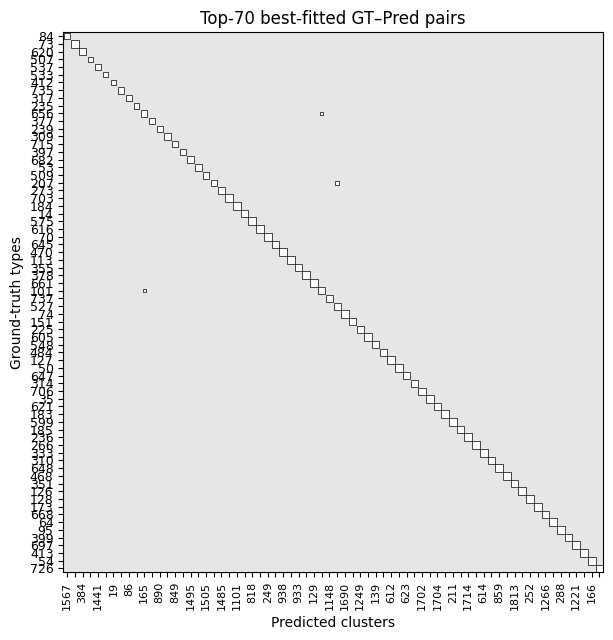

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 8, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 1191))

In [82]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',        # 或 'overlap' / 'counts'
    top_k_pairs=70,           # 只保留前10组最佳配对
    corner='tr',              # 左上；改成 'tr' 就是右上
    title='Top-70 best-fitted GT–Pred pairs'
)


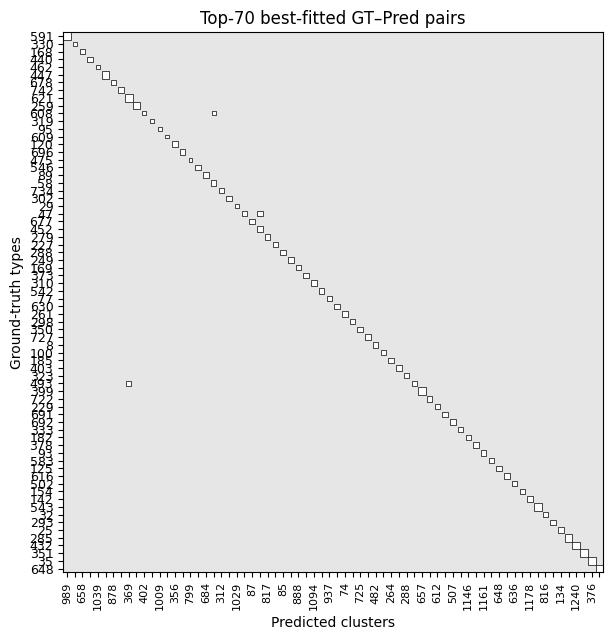

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 1068))

In [83]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(pca_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',        # 或 'overlap' / 'counts'
    top_k_pairs=70,           # 只保留前10组最佳配对
    corner='tr',              # 左上；改成 'tr' 就是右上
    title='Top-70 best-fitted GT–Pred pairs'
)


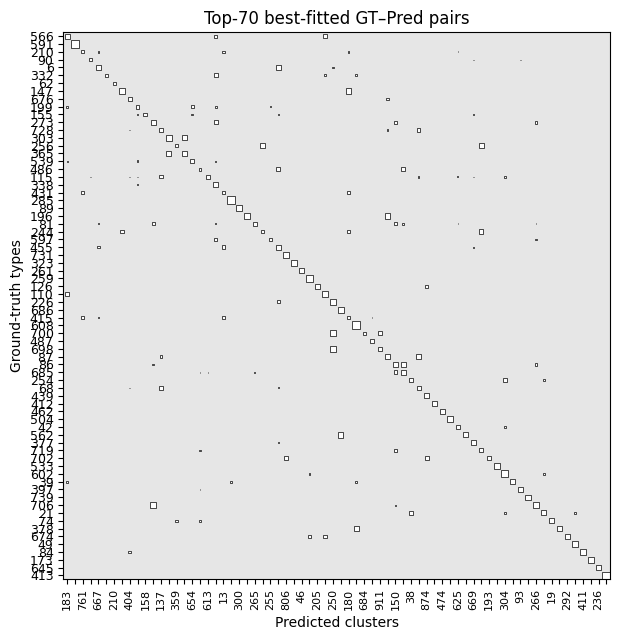

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 3, 0, ..., 0, 6, 2],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 542))

In [84]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)


plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',        # 或 'overlap' / 'counts'
    top_k_pairs=70,           # 只保留前10组最佳配对
    corner='tr',              # 左上；改成 'tr' 就是右上
    title='Top-70 best-fitted GT–Pred pairs'
)


In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)


TypeError: plot_hinton_gt_vs_pred() got an unexpected keyword argument 'top_by'

C:\Users\ROG\AppData\Local\Temp\ipykernel_22484\3264396361.py:27: RuntimeWarning: divide by zero encountered in log2
  max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))


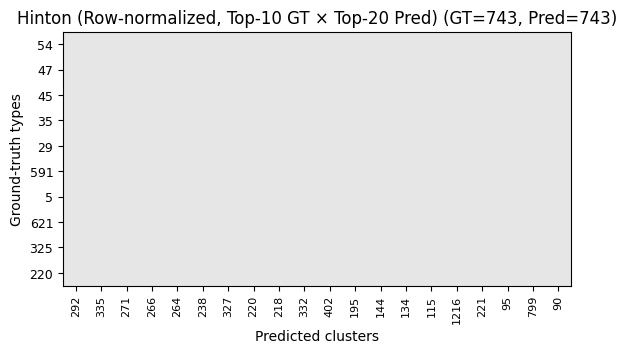

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  1,  0, ...,  0,  0,  0],
       [ 0,  0,  1, ...,  0,  0,  0],
       ...,
       [ 0,  1,  0, ..., 56,  1,  0],
       [ 0,  0,  0, ...,  0,  2,  0],
       [ 0,  0,  0, ...,  0,  0,  1]], shape=(743, 743))

In [58]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(pca_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)

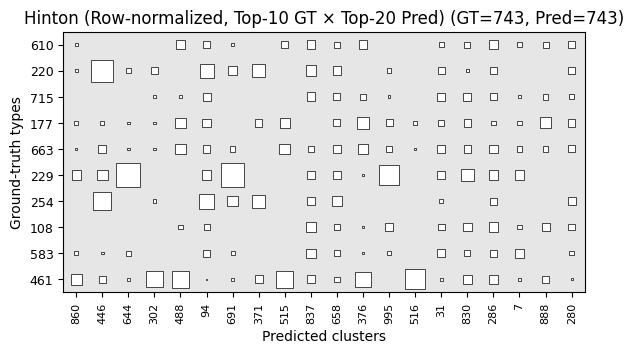

array([[22,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  2,  0],
       [ 0,  0,  0, ...,  0,  0,  6],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 542))

In [61]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)

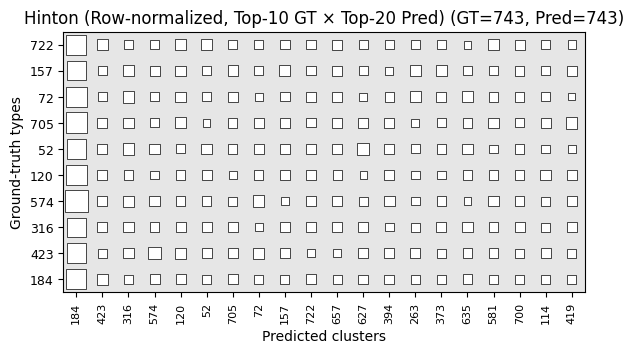

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 3, 0],
       [0, 0, 0, ..., 0, 0, 1]], shape=(743, 743))

In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(random_assignment_optimistic)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)

In [ ]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=False,  # 默认 False：不再强制方形，避免巨大留白

    # ===== 新增：可读性增强选项（全部可选） =====
    sort_rows='none',     # 'none' | 'entropy' | 'peak'  (先行排序)
    sort_cols='none',     # 'none' | 'mass'    (后列排序)
    top_k_rows=None,      # 仅保留Top-K行（不合并其它）
    merge_weak_cols=None, # float in (0,1): 将列总质量 < 该比例 的列合并为 'Other'
    sparsify=None,        # dict e.g. {'tau':0.01} 或 {'top_r':3}
    renderer='hinton',    # 'hinton' | 'heatmap'
    annotate_top1=False,  # 热力图上标注每行Top-1百分比
    figsize=None          # 手动指定画布大小；不填则自适应
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ---------- 基本：计数矩阵 ----------
    C = contingency_matrix(y_gt, y_pred)

    # 对齐（可选）
    if align:
        try:
            from scipy.optimize import linear_sum_assignment
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            pass

    # 标签兜底
    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    # 备份：归一化前的计数矩阵（用于合并/排序的 count 依据）
    C_count = C.astype(float)

    # ---------- 归一化 ----------
    C_plot = C_count.copy()
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # ---------- 行排序 ----------
    if sort_rows in ('entropy', 'peak'):
        if normalize != 'row':
            # 行排序建议在 row-normalized 后进行，若不是，则用行归一化副本度量
            R = C_plot.copy()
            if normalize != 'row':
                rs = R.sum(axis=1, keepdims=True); rs[rs == 0] = 1
                R = R / rs
        else:
            R = C_plot

        if sort_rows == 'entropy':
            eps = 1e-12
            ent = -(R * np.log(R + eps)).sum(axis=1)   # 熵小 = 更聚合
            row_order = np.argsort(ent)                # 从聚合到分散
        else:  # 'peak'
            peak_val = R.max(axis=1)
            peak_pos = R.argmax(axis=1)
            row_order = np.lexsort((-peak_val, peak_pos))  # 先按峰位置分组，再按峰值降序

        C_plot = C_plot[row_order]; row_names = [row_names[i] for i in row_order]
        C_count = C_count[row_order]

    # ---------- Top-K 行（按“行强度”挑） ----------
    if (top_k_rows is not None) and (top_k_rows < C_plot.shape[0]):
        # 行强度：若已 row-normalized，用 peak；否则用原始计数行和
        if normalize == 'row':
            strength = C_plot.max(axis=1)
        else:
            strength = C_count.sum(axis=1)
        keep_i = np.argsort(-strength)[:top_k_rows]
        C_plot = C_plot[keep_i]; row_names = [row_names[i] for i in keep_i]
        C_count = C_count[keep_i]

    # ---------- 列排序 ----------
    if sort_cols == 'mass':
        # 列强度：若是 row-norm，用列和（质量）；否则也可用计数列和
        col_strength = C_plot.sum(axis=0) if normalize == 'row' else C_count.sum(axis=0)
        col_order = np.argsort(-col_strength)
        C_plot = C_plot[:, col_order]; col_names = [col_names[j] for j in col_order]
        C_count = C_count[:, col_order]

    # ---------- 合并长尾列 ----------
    if isinstance(merge_weak_cols, float) and (0 < merge_weak_cols < 1):
        # 用“列总质量占比”做阈值（与 normalize='row' 协调较好）
        col_mass = C_plot.sum(axis=0)
        total_mass = col_mass.sum()
        keep = np.where(col_mass / (total_mass + 1e-12) >= merge_weak_cols)[0]
        rest = np.setdiff1d(np.arange(C_plot.shape[1]), keep)
        if rest.size > 0:
            other_col = C_plot[:, rest].sum(axis=1, keepdims=True)
            C_plot = np.hstack([C_plot[:, keep], other_col])
            col_names = [col_names[j] for j in keep] + ['Other']

            # 同步计数矩阵（若后续还要用到）
            other_col_cnt = C_count[:, rest].sum(axis=1, keepdims=True)
            C_count = np.hstack([C_count[:, keep], other_col_cnt])

    # ---------- 稀疏化 ----------
    if isinstance(sparsify, dict) and C_plot.size > 0:
        Cp = C_plot.copy()
        if 'tau' in sparsify:  # 绝对阈值
            tau = float(sparsify['tau'])
            Cp[Cp < tau] = 0.0
        if 'top_r' in sparsify:
            r = int(sparsify['top_r'])
            # 每行仅保留 Top-r
            idx = np.argsort(-Cp, axis=1)[:, :r]
            mask = np.zeros_like(Cp, dtype=bool)
            rows = np.arange(Cp.shape[0])[:, None]
            mask[rows, idx] = True
            Cp[~mask] = 0.0
        C_plot = Cp

    # ---------- 画图 ----------
    H, W = C_plot.shape
    if pad_to_square:
        n = max(H, W)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:H, :W] = C_plot
        Hpad, Wpad = S.shape
    else:
        S = C_plot
        Hpad, Wpad = H, W

    # 自适应画布
    if figsize is None:
        fig_w = max(6, min(16, 6 + 0.02 * W))
        fig_h = max(3, min(10, 3 + 0.25 * (H)))
        figsize = (fig_w, fig_h)

    fig, ax = plt.subplots(figsize=figsize)

    if renderer == 'heatmap':
        im = ax.imshow(S[:H, :W], aspect='auto', cmap='Greys')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Row-normalized weight' if normalize == 'row' else 'Value')
        # Top-1 标注（在热力图模式下更合适）
        if annotate_top1 and H > 0 and W > 0:
            rmax = C_plot.argmax(axis=1)
            vmax = C_plot[np.arange(H), rmax]
            for i, (j, v) in enumerate(zip(rmax, vmax)):
                ax.text(j+0.5, i+0.5, f'{v*100:.0f}%', ha='center', va='center', fontsize=7)
    else:
        hinton(ax, S)  # 使用你现有的hinton方块渲染

    ax.set_title(f"{title} (GT={contingency_matrix(y_gt, y_pred).shape[0]}, Pred={contingency_matrix(y_gt, y_pred).shape[1]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    # 刻度仅针对裁剪后的真实区域
    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    # 稀疏显示X轴标签，避免重叠
    if W > 60:
        step = int(np.ceil(W / 60))
        xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
    else:
        xticklabels = col_names[:W]
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names[:H], fontsize=9)

    plt.tight_layout()
    plt.show()
    return C


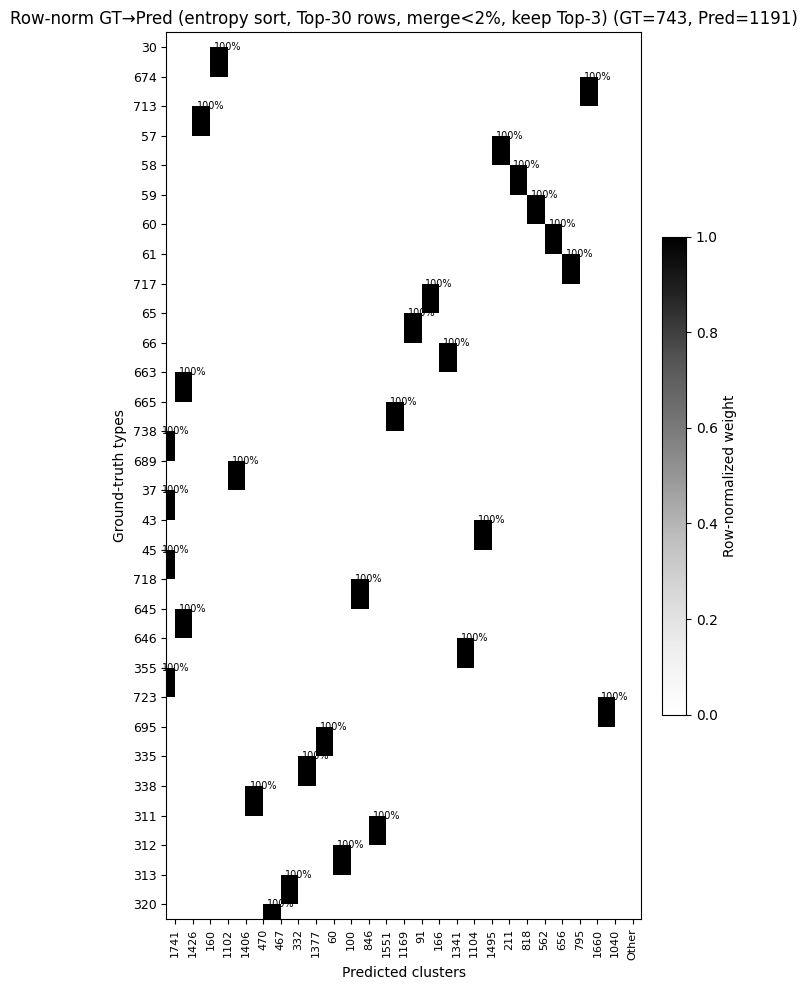

array([[24,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 20, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0, 41,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 743))

In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Row-norm GT→Pred (entropy sort, Top-30 rows, merge<2%, keep Top-3)',
    sort_rows='entropy', sort_cols='mass',
    top_k_rows=30,
    merge_weak_cols=0.02,
    sparsify={'top_r': 3, 'tau': 0.01},  # 两者可择一或同时用
    renderer='heatmap',
    annotate_top1=True,
    pad_to_square=False
)


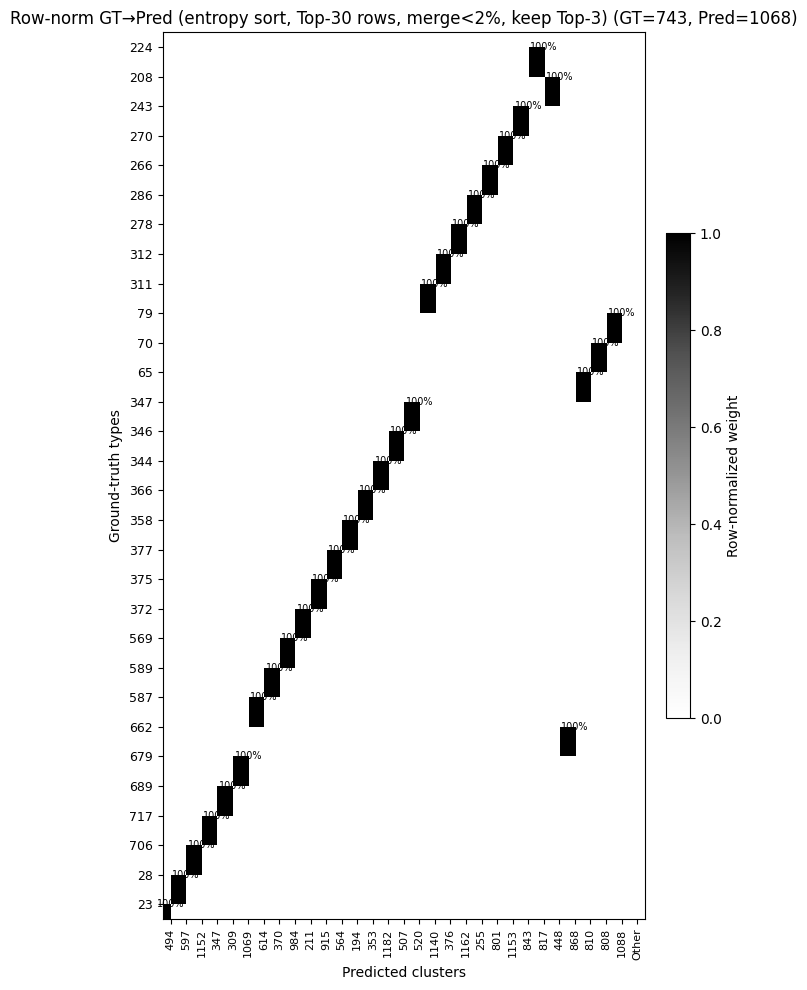

array([[3, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [2, 0, 0, ..., 1, 4, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 743))

In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(pca_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Row-norm GT→Pred (entropy sort, Top-30 rows, merge<2%, keep Top-3)',
    sort_rows='entropy', sort_cols='mass',
    top_k_rows=30,
    merge_weak_cols=0.02,
    sparsify={'top_r': 3, 'tau': 0.01},  # 两者可择一或同时用
    renderer='heatmap',
    annotate_top1=True,
    pad_to_square=False
)


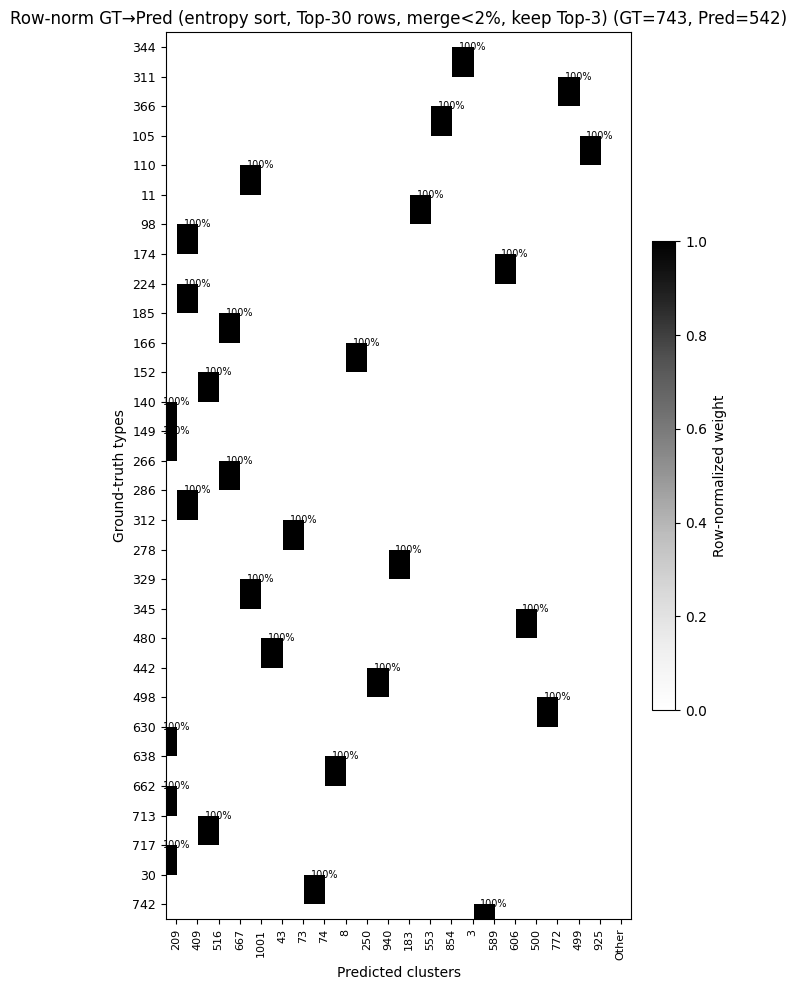

array([[11,  0,  3, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  2, ...,  0,  1,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  1, ...,  0,  5,  4],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 542))

In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Row-norm GT→Pred (entropy sort, Top-30 rows, merge<2%, keep Top-3)',
    sort_rows='entropy', sort_cols='mass',
    top_k_rows=30,
    merge_weak_cols=0.02,
    sparsify={'top_r': 3, 'tau': 0.01},  # 两者可择一或同时用
    renderer='heatmap',
    annotate_top1=True,
    pad_to_square=False
)


In [126]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=False,
    top_k_rows=None, top_k_cols=None,
    top_by='count'
):
    C = contingency_matrix(y_gt, y_pred)

    if align:
        try:
            from scipy.optimize import linear_sum_assignment
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            pass

    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    # --- 归一化（若需要）---
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    # ========= 核心：Radix/多键稳定排序（先排再选）=========
    # 解释：
    #   1) 以行主峰所在列 index（peak_col）为“主键”，让相同主峰列的行聚在一起（形成对角带）
    #   2) 次键：主峰值 peak_val 递减（越“纯”越靠前）
    #   3) 第三键：行规模 row_mass 递减（样本多的更靠前，避免小类占据前面）
    # 说明：np.lexsort(keys) 以 "最后一个键" 为主键；因此把 (第三键, 次键, 主键) 依次放进去
    peak_col = C_plot.argmax(axis=1)
    peak_val = C_plot[np.arange(C_plot.shape[0]), peak_col]
    row_mass = C.sum(axis=1)  # 用原始计数衡量行规模

    order = np.lexsort((
        -row_mass,        # 第三键：规模大优先
        -peak_val,        # 次键：主峰值大优先
         peak_col         # 主键：主峰列的索引（把同列聚在一起）
    ))
    C_plot = C_plot[order, :]
    row_names = [row_names[i] for i in order]
    # ========= 排序结束 =========

    # ---- 仅裁剪 Top-K 行（排序后再选）----
    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        C_plot = C_plot[:top_k_rows, :]
        row_names = row_names[:top_k_rows]

    # ---- 仅裁剪 Top-K 列（不合并“Other”）----
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        if top_by == 'count':
            col_score = C.sum(axis=0)
        else:
            col_score = C_plot.sum(axis=0)
        top_j = np.argsort(col_score)[::-1][:top_k_cols]
        C_plot = C_plot[:, top_j]
        col_names = [col_names[j] for j in top_j]

    # ---- 不再 pad 成方阵（避免大片灰色留白）----
    S = C_plot
    H, W = S.shape

    fig_w = max(6, min(16, 0.03 * W + 6))
    fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")  # 修正Pred显示
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    if W > 60:
        step = int(np.ceil(W / 60))
        xticklabels = [lbl if i % step == 0 else '' for i, lbl in enumerate(col_names)]
    else:
        xticklabels = col_names
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names, fontsize=9)

    plt.tight_layout()
    plt.show()
    return C



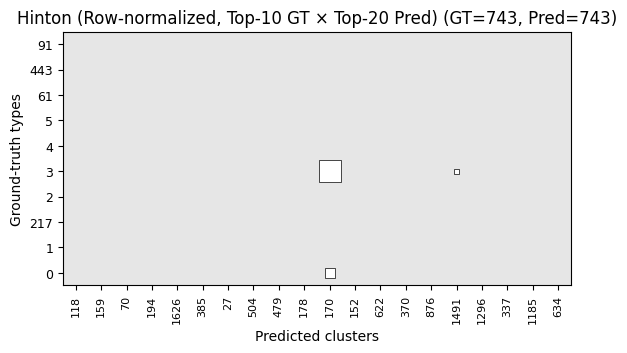

array([[19,  0,  0, ...,  0,  0,  0],
       [ 0, 22,  0, ...,  0,  0,  0],
       [ 0,  0, 41, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 30,  0,  0],
       [ 0,  0,  0, ...,  0, 13,  0],
       [ 0,  0,  0, ...,  0,  0,  2]], shape=(743, 743))

In [127]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)


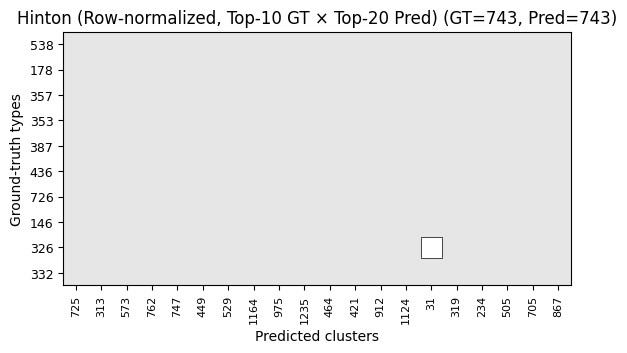

array([[3, 1, 0, ..., 0, 0, 0],
       [0, 3, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 3, 0, 0],
       [0, 1, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]], shape=(743, 743))

In [128]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(pca_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)

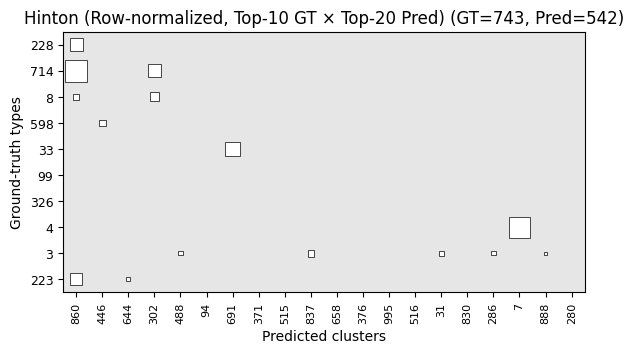

array([[ 4,  0,  0, ...,  0,  1,  0],
       [ 0,  9,  0, ...,  0,  0,  0],
       [ 0,  0,  1, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 11,  0,  0],
       [ 0,  0,  0, ...,  0,  5,  0],
       [ 0,  0,  0, ...,  0,  0,  2]], shape=(743, 542))

: 

In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)

In [ ]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(random_assignment_optimistic)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized, Top-10 GT × Top-20 Pred)',
    top_k_rows=10, top_k_cols=20, top_by='count',
    pad_to_square=False
)